Ноутбук показывает:

1. Шесть геометрий в симметричном виде на одном полотне.
2. Аппроксимацию канала цилиндрами и конусами, включая трубу с дыркой.
3. Сравнение скорости работы solver-ов.
4. Сравнение относительной ошибки относительно выбранного reference solver и показ худшего случая в dB.

In [10]:
import math
import statistics
import matplotlib.pyplot as plt
import vt_all_solvers_wrapper as vt
from base_range_library import range_library

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

# Пересобираем solver CLI, чтобы не использовать старый несовместимый exe.
vt.build_binary(rebuild=True)

WindowsPath('C:/Users/George.LAPTOP-TLP259VH/Desktop/webster/bin/windows/vt_all_solvers_cli.exe')

In [11]:
def magnitude_to_db(magnitude, eps=1e-12):
    return [20.0 * math.log10(max(abs(v), eps)) for v in magnitude]


def make_demo_geometries(seed=1):
    return {
        "cylinder": vt.make_cylinder_geometry(length_m=1.0, area_m2=8.0e-4),
        "conical": vt.make_conical_geometry(length_m=1.0, area_in_m2=4.0e-4, area_out_m2=3.0e-3),
        "three_point": vt.make_three_point_geometry(
            length_m=1.0,
            area_left_m2=5.0e-4,
            area_middle_m2=2.2e-3,
            area_right_m2=9.0e-4,
        ),
        "tube_with_hole": vt.make_tube_with_hole_geometry(
            length_m=1.0,
            base_width_m=0.05,
            random=False,
            hole_center_m=0.55,
        ),
        "random_smooth": vt.make_random_smooth_geometry(
            length_m=1.0,
            dx_m=0.025,
            area0_m2=1.1e-3,
            amp=0.28,
            n_harmonics=6,
            seed=seed,
        ),
        "random_piecewise": vt.make_random_piecewise_geometry(
            length_m=1.0,
            mean_width_m=0.055,
            section_count=7,
            width_spread=0.33,
            seed=seed,
        ),
    }


def make_random_suite_from_range_library(range_library, n_cases=16, seed0=1000):
    suite = {}
    for i in range(n_cases):
        geom = vt.make_geometry_from_range_library("random", range_library, seed=seed0 + i)
        suite[f"sample_{i + 1:02d}"] = geom
    return suite


def benchmark_speed_from_range_library(
    range_library,
    n_runs=12,
    geometry_kind="random",
    solvers=("cylinder", "cone", "arma", "webster"),
    base_config=None,
    acoustics=None,
):
    if base_config is None:
        base_config = vt.SolverConfig(
            sections=24,
            points=256,
            f_min_hz=100.0,
            f_max_hz=3000.0,
            grid="linear",
            beta_loss_np_per_m=0.02,
            spatial_nodes=41,
            signal_sample_rate_hz=16000.0,
            signal_duration_s=0.04,
        )
    if acoustics is None:
        acoustics = vt.AcousticConfig()

    vt.build_binary()
    times_by_solver = {solver: [] for solver in solvers}
    geometries = []

    for run_idx in range(n_runs):
        geom = vt.make_geometry_from_range_library(geometry_kind, range_library, seed=run_idx + 1)
        geometries.append(geom)

        for solver_name in solvers:
            config = vt.SolverConfig(
                solver=solver_name,
                sections=base_config.sections,
                points=base_config.points,
                f_min_hz=base_config.f_min_hz,
                f_max_hz=base_config.f_max_hz,
                grid=base_config.grid,
                beta_loss_np_per_m=base_config.beta_loss_np_per_m,
                signal_sample_rate_hz=base_config.signal_sample_rate_hz,
                signal_duration_s=base_config.signal_duration_s,
                signal_f0_hz=base_config.signal_f0_hz,
                signal_f1_hz=base_config.signal_f1_hz,
                signal_amplitude=base_config.signal_amplitude,
                spatial_nodes=base_config.spatial_nodes,
                cfl=base_config.cfl,
                observation_node=base_config.observation_node,
            )

            import time
            t0 = time.perf_counter()
            _ = vt.solve(geometry=geom, config=config, acoustics=acoustics, rebuild=False)
            t1 = time.perf_counter()
            times_by_solver[solver_name].append(t1 - t0)

    return times_by_solver, geometries


def summarize_relative_errors(benchmark_results, reference_solver="cone"):
    solvers = list(benchmark_results[0].comparison.results.keys())
    summary = {}
    for solver in solvers:
        vals = [item.relative_errors[solver].mean_rel_mag_err for item in benchmark_results]
        summary[solver] = statistics.mean(vals)
    non_reference = [solver for solver in solvers if solver != reference_solver]
    worst_solver = max(
        non_reference,
        key=lambda solver: max(item.relative_errors[solver].mean_rel_mag_err for item in benchmark_results),
    )
    worst_case = max(
        benchmark_results,
        key=lambda item: item.relative_errors[worst_solver].mean_rel_mag_err,
    )
    return summary, worst_solver, worst_case


## 1. Шесть геометрий в симметричном виде

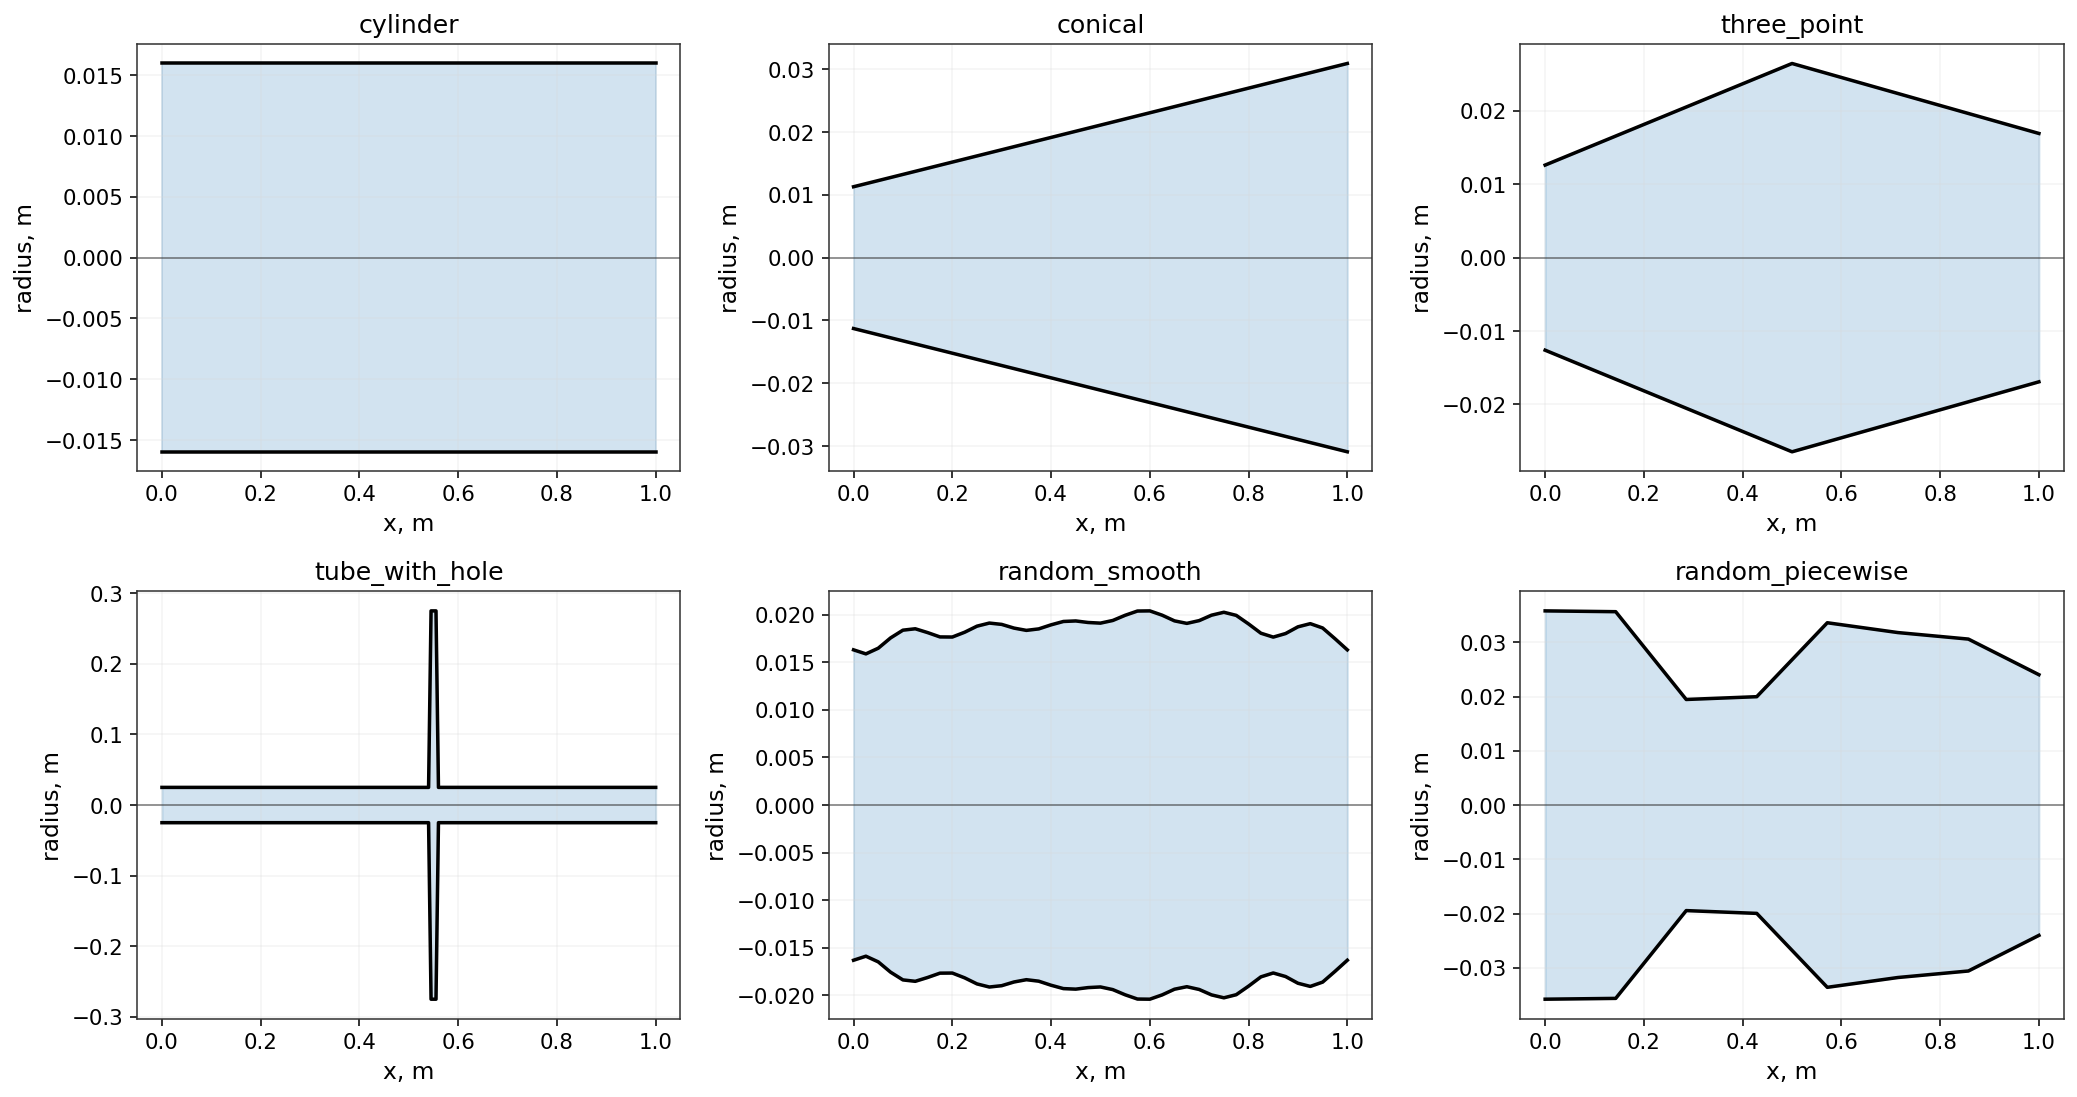

In [12]:
geometries = make_demo_geometries(seed=2)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (name, geom) in zip(axes.ravel(), geometries.items()):
    vt.plot_geometry(
        geom,
        mode="symmetric",
        ax=ax,
        title=name,
        equal_aspect=False,
        linewidth=1.8,
    )

plt.tight_layout()
plt.show()

## 1b. Аппроксимация канала цилиндрами и конусами

Верхний ряд показывает обычный канал, нижний ряд показывает трубу с дыркой.

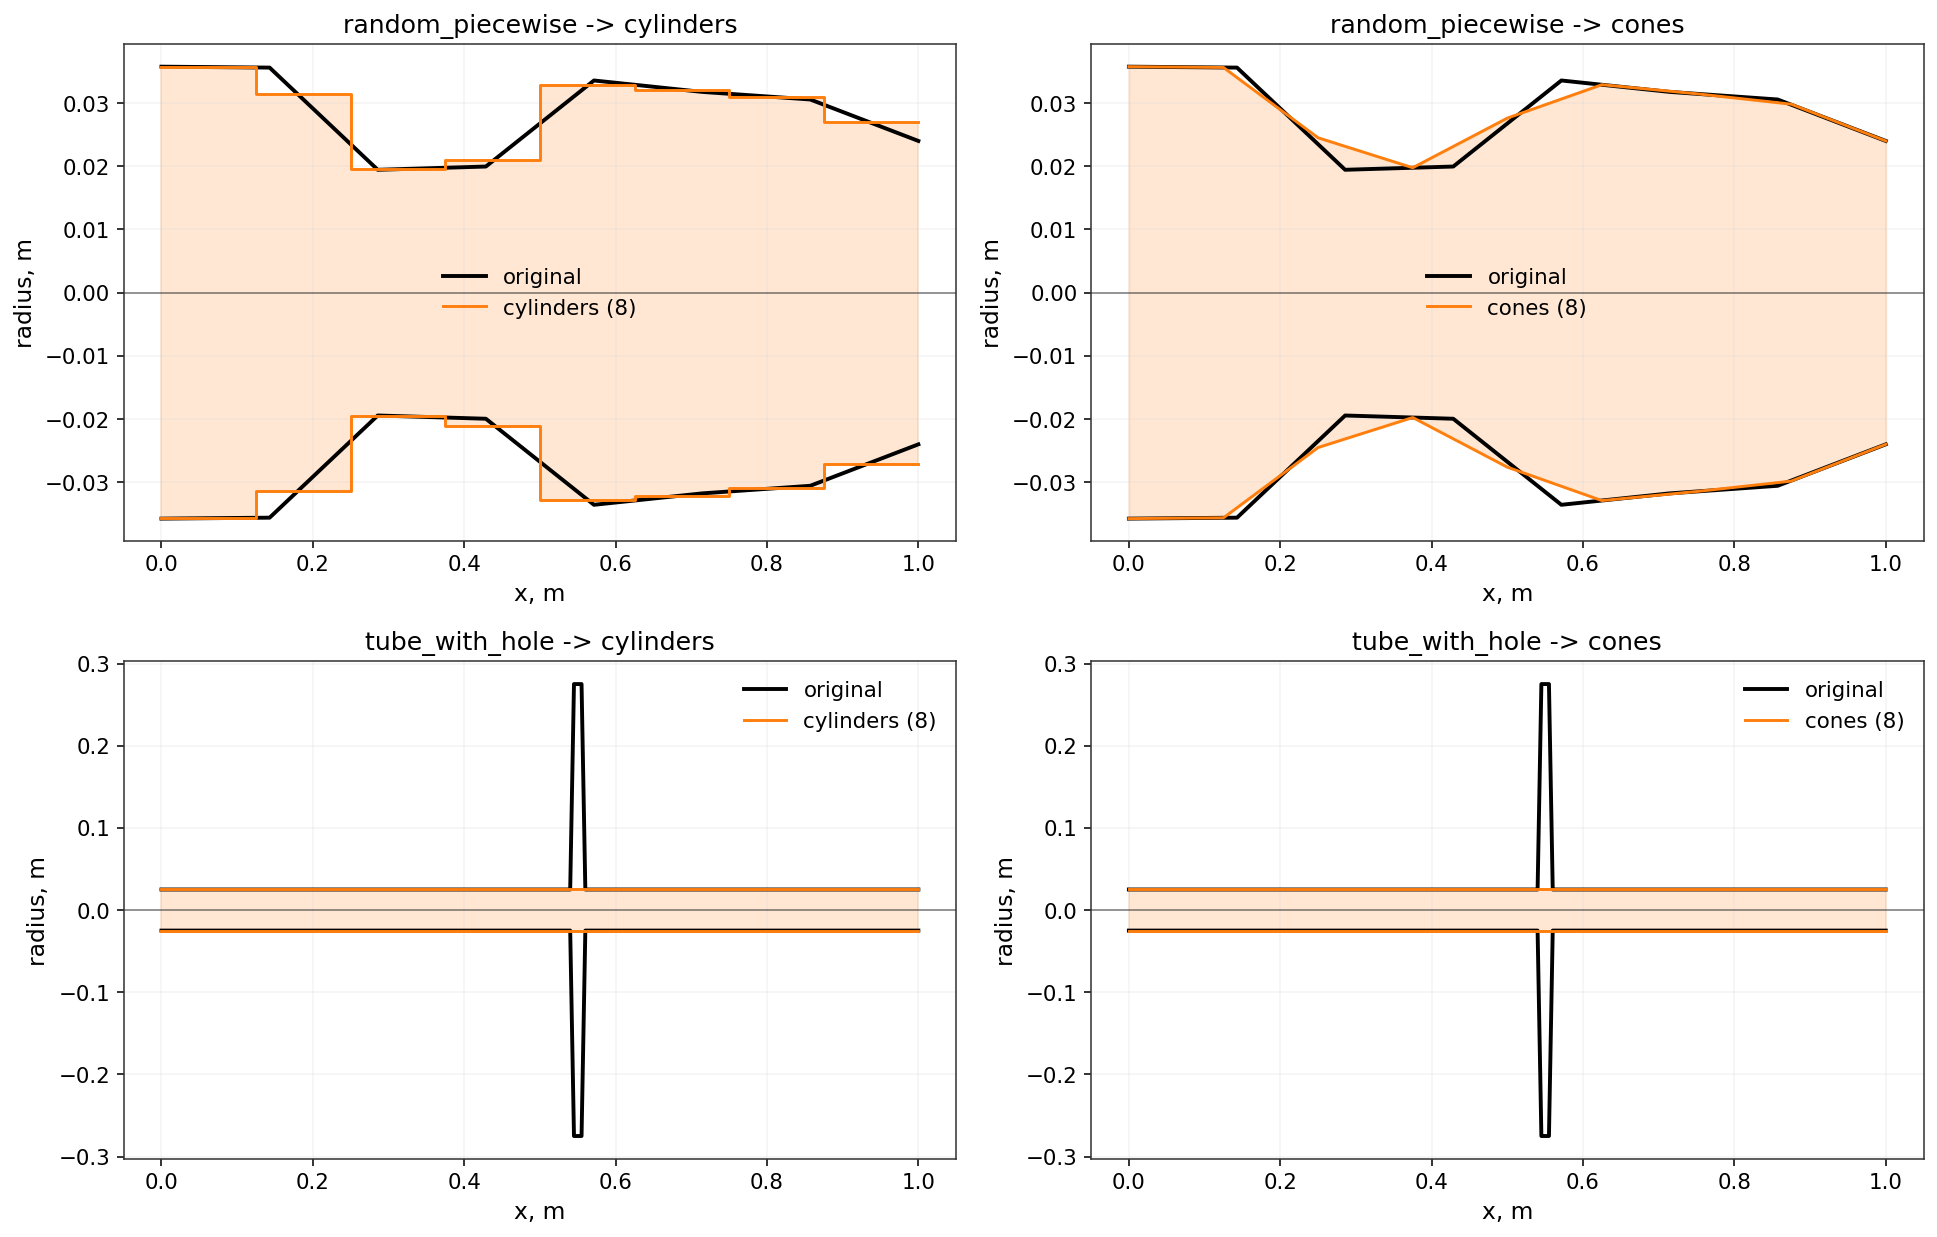

In [13]:
geom_main = geometries["random_piecewise"]
geom_hole = geometries["tube_with_hole"]
section_count = 8

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

vt.plot_geometry_approximation(
    geom_main,
    section_count=section_count,
    approx="cylinders",
    mode="symmetric",
    ax=axes[0, 0],
    title="random_piecewise -> cylinders",
    equal_aspect=False,
)
vt.plot_geometry_approximation(
    geom_main,
    section_count=section_count,
    approx="cones",
    mode="symmetric",
    ax=axes[0, 1],
    title="random_piecewise -> cones",
    equal_aspect=False,
)
vt.plot_geometry_approximation(
    geom_hole,
    section_count=section_count,
    approx="cylinders",
    mode="symmetric",
    ax=axes[1, 0],
    title="tube_with_hole -> cylinders",
    equal_aspect=False,
)
vt.plot_geometry_approximation(
    geom_hole,
    section_count=section_count,
    approx="cones",
    mode="symmetric",
    ax=axes[1, 1],
    title="tube_with_hole -> cones",
    equal_aspect=False,
)

plt.tight_layout()
plt.show()

## 2. Сравнение скорости работы

In [14]:
speed_config = vt.SolverConfig(
    sections=24,
    points=256,
    f_min_hz=100.0,
    f_max_hz=3000.0,
    grid="linear",
    beta_loss_np_per_m=0.02,
    spatial_nodes=41,
    signal_sample_rate_hz=16000.0,
    signal_duration_s=0.04,
)
acoustics = vt.AcousticConfig()
speed_solvers = ("cylinder", "cone", "arma", "webster")

times_by_solver, speed_geometries = benchmark_speed_from_range_library(
    range_library,
    n_runs=12,
    geometry_kind="random",
    solvers=speed_solvers,
    base_config=speed_config,
    acoustics=acoustics,
)

mean_times = {solver: statistics.mean(times) for solver, times in times_by_solver.items()}
mean_times

{'cylinder': 0.034934425000453,
 'cone': 0.01658280833362369,
 'arma': 0.01796875833224476,
 'webster': 0.05569877500026147}

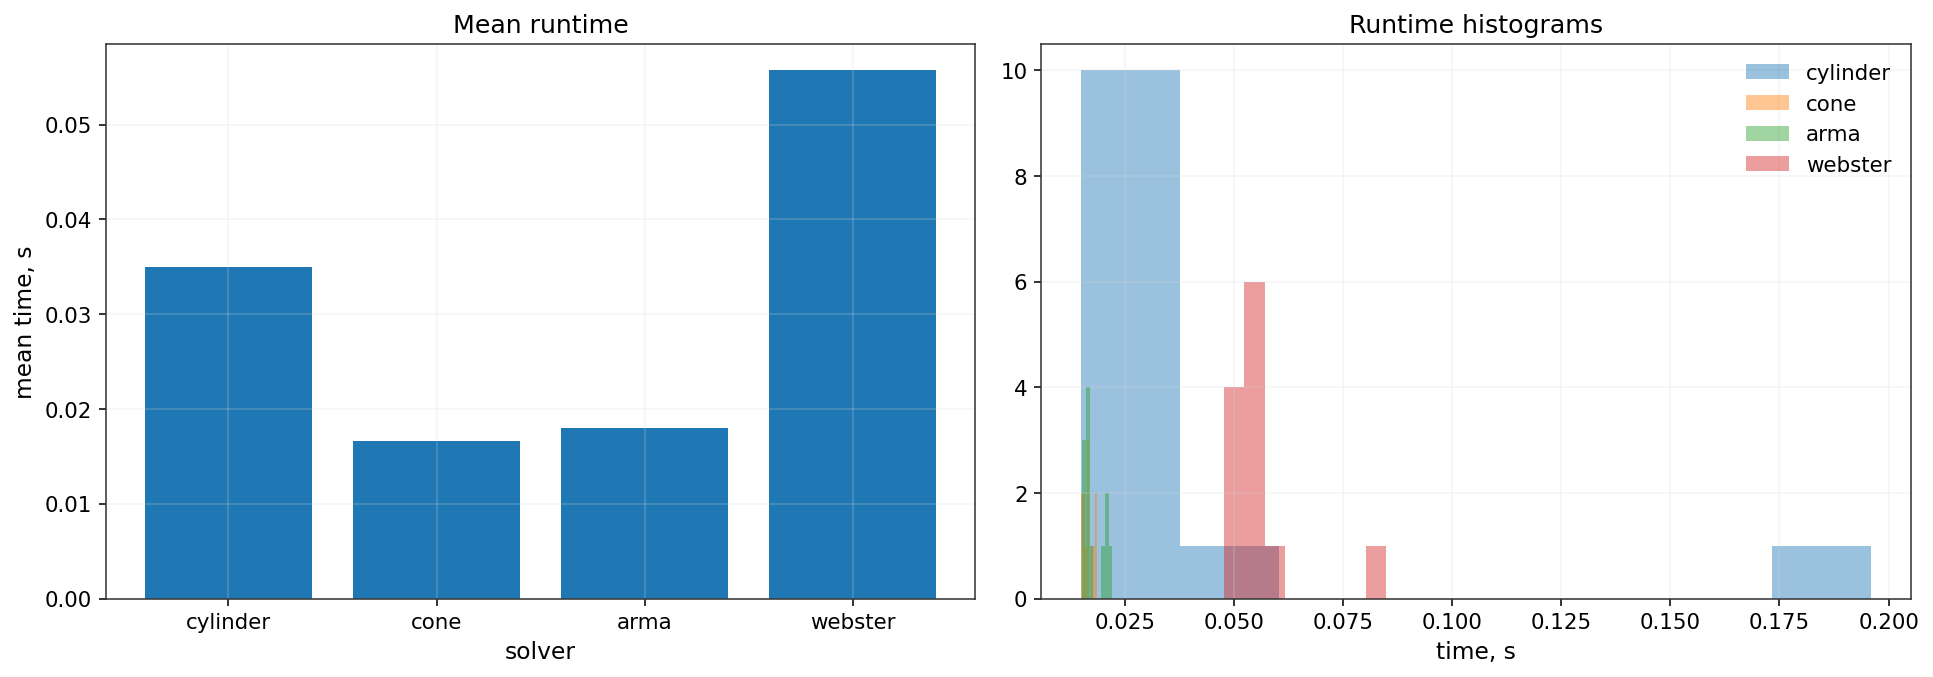

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

solver_names = list(times_by_solver.keys())
axes[0].bar(solver_names, [mean_times[name] for name in solver_names])
axes[0].set_title("Mean runtime")
axes[0].set_xlabel("solver")
axes[0].set_ylabel("mean time, s")

for solver_name in solver_names:
    axes[1].hist(times_by_solver[solver_name], bins=8, alpha=0.45, label=solver_name)
    axes[1].set_title("Runtime histograms")
    axes[1].set_xlabel("time, s")
    axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Относительная ошибка относительно reference solver и худший случай в dB

In [16]:
reference_solver = "cone"
quality_solvers = ("cylinder", "cone", "arma")

quality_config = vt.SolverConfig(
    sections=51,
    points=256,
    f_min_hz=100.0,
    f_max_hz=3000.0,
    grid="linear",
    beta_loss_np_per_m=0.02,
    spatial_nodes=41,
    signal_sample_rate_hz=16000.0,
    signal_duration_s=0.04,
)

quality_suite = make_random_suite_from_range_library(range_library, n_cases=16, seed0=300)

benchmark_results = vt.benchmark_geometry_suite(
    solvers=quality_solvers,
    base_config=quality_config,
    acoustics=acoustics,
    geometry_suite=quality_suite,
    reference_solver=reference_solver,
)

mean_rel_errors, worst_solver, worst_case = summarize_relative_errors(
    benchmark_results,
    reference_solver=reference_solver,
)

mean_rel_errors

{'cylinder': 0.5375567720700556, 'cone': 0.0, 'arma': 0.5375567720700556}

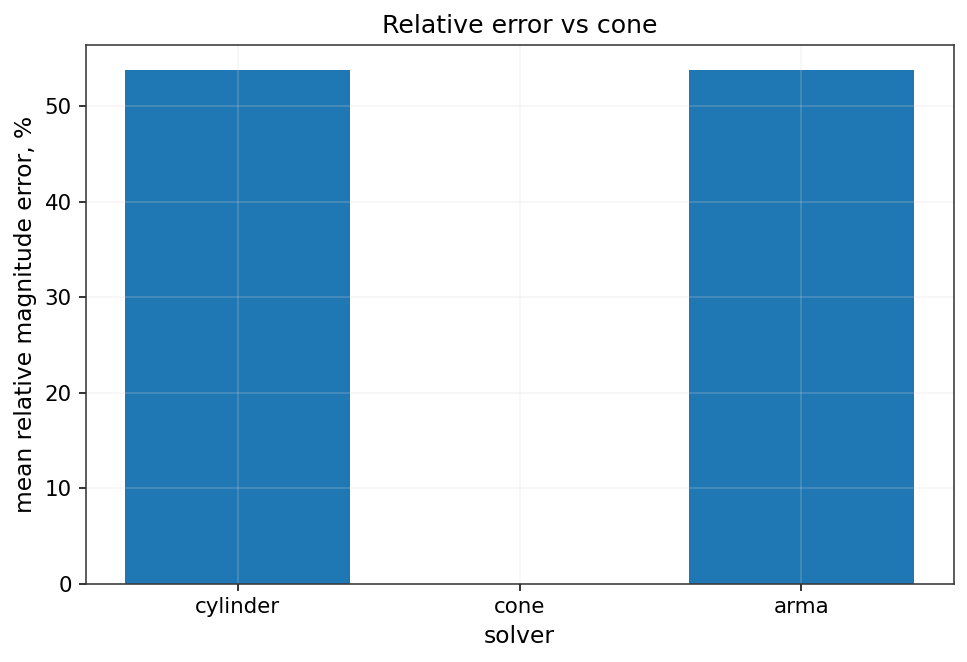

worst solver: cylinder
worst geometry: sample_07
worst-case mean relative error, % = 194.6629475887535
worst-case max relative error, % = 740.8621608727509


In [17]:
error_solver_names = list(mean_rel_errors.keys())
error_values_percent = [100.0 * mean_rel_errors[name] for name in error_solver_names]

plt.figure(figsize=(8, 5))
plt.bar(error_solver_names, error_values_percent)
plt.xlabel("solver")
plt.ylabel("mean relative magnitude error, %")
plt.title(f"Relative error vs {reference_solver}")
plt.show()

print("worst solver:", worst_solver)
print("worst geometry:", worst_case.geometry_name)
print(
    "worst-case mean relative error, % =",
    100.0 * worst_case.relative_errors[worst_solver].mean_rel_mag_err,
)
print(
    "worst-case max relative error, % =",
    100.0 * worst_case.relative_errors[worst_solver].max_rel_mag_err,
)


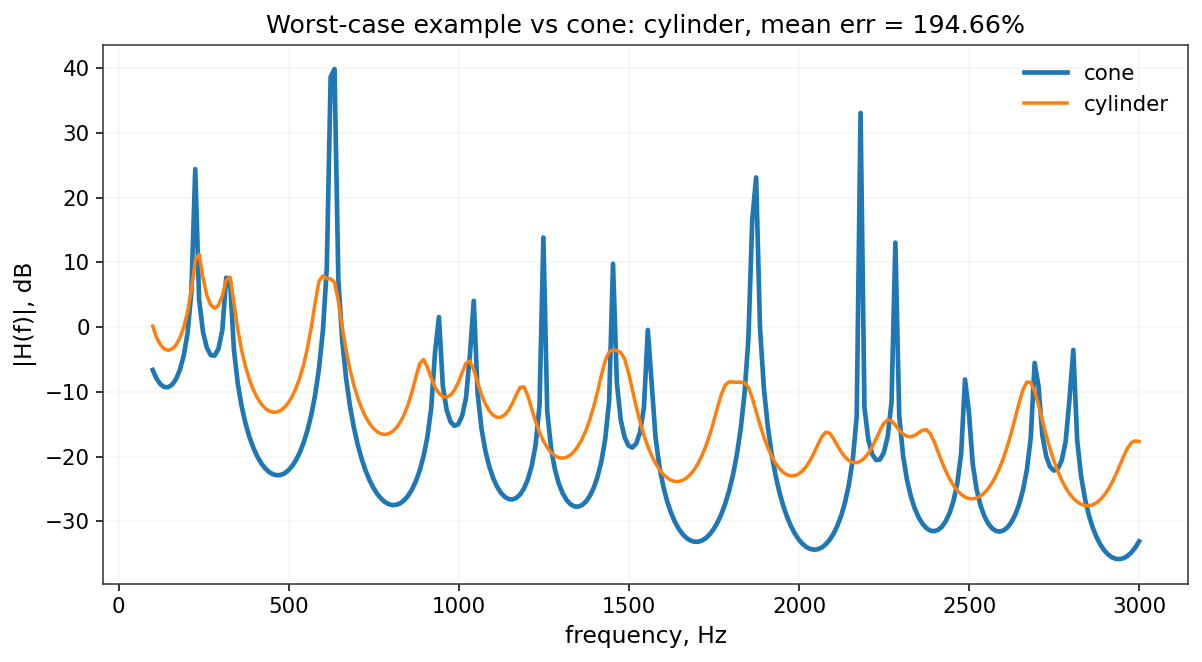

In [18]:
ref_result = worst_case.comparison.results[reference_solver]
bad_result = worst_case.comparison.results[worst_solver]

plt.figure(figsize=(10, 5))
plt.plot(
    ref_result.frequencies_hz,
    magnitude_to_db(ref_result.magnitude),
    label=reference_solver,
    linewidth=2.4,
)
plt.plot(
    bad_result.frequencies_hz,
    magnitude_to_db(bad_result.magnitude),
    label=worst_solver,
    linewidth=1.8,
)
plt.xlabel("frequency, Hz")
plt.ylabel("|H(f)|, dB")
plt.title(
    f"Worst-case example vs {reference_solver}: {worst_solver}, "
    f"mean err = {100.0 * worst_case.relative_errors[worst_solver].mean_rel_mag_err:.2f}%"
)
plt.legend()
plt.show()

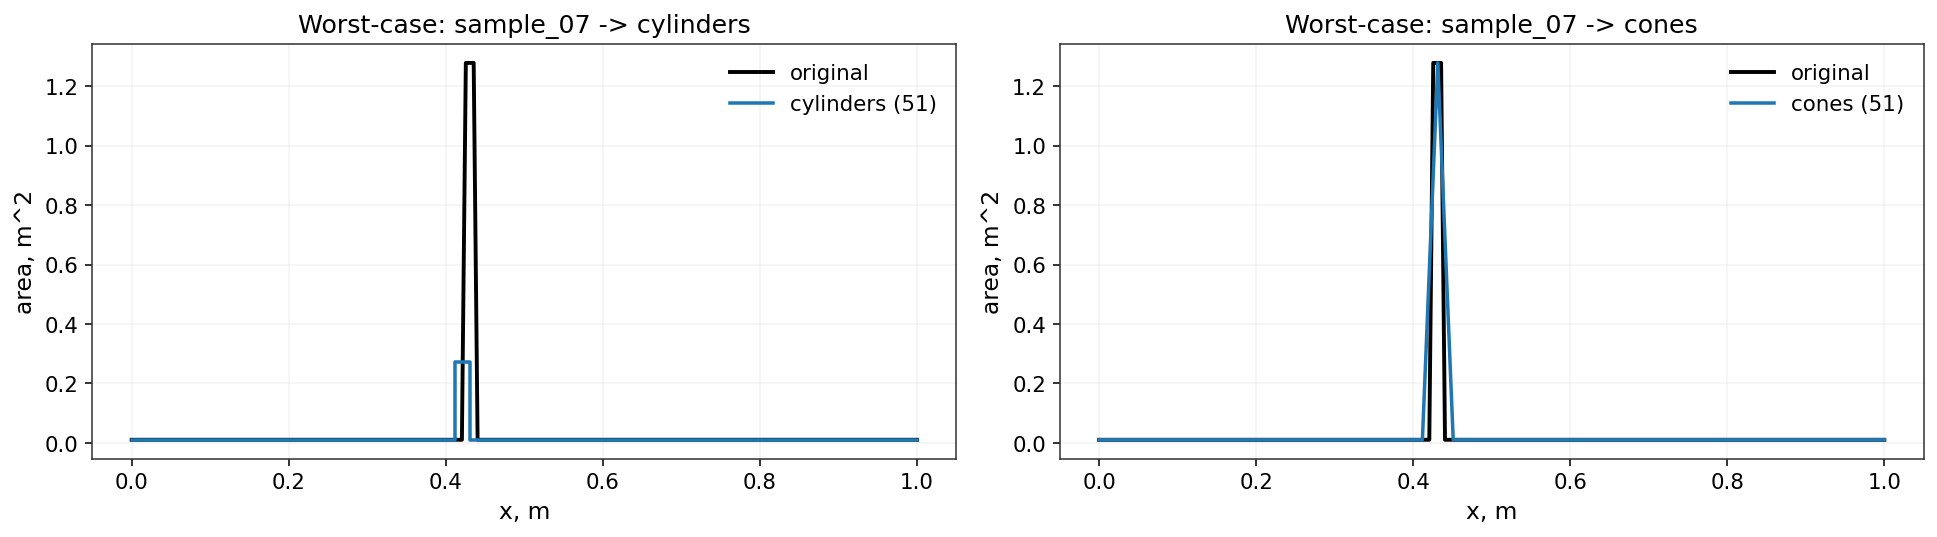

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

vt.plot_geometry_approximation(
    worst_case.geometry,
    section_count=quality_config.sections,
    approx="cylinders",
    mode="graph",
    ax=axes[0],
    title=f"Worst-case: {worst_case.geometry_name} -> cylinders",
    equal_aspect=False,
    linewidth_original=2.0,
    linewidth_approx=1.8,
)

vt.plot_geometry_approximation(
    worst_case.geometry,
    section_count=quality_config.sections,
    approx="cones",
    mode="graph",
    ax=axes[1],
    title=f"Worst-case: {worst_case.geometry_name} -> cones",
    equal_aspect=False,
    linewidth_original=2.0,
    linewidth_approx=1.8,
)

plt.tight_layout()
plt.show()

<Axes: title={'center': 'cylinders approximation'}, xlabel='x, m', ylabel='radius, m'>

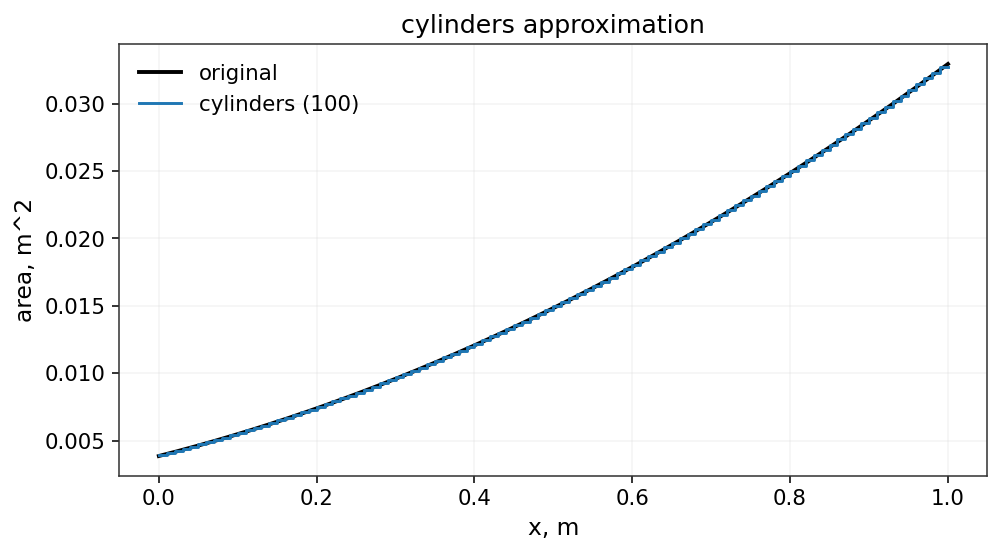

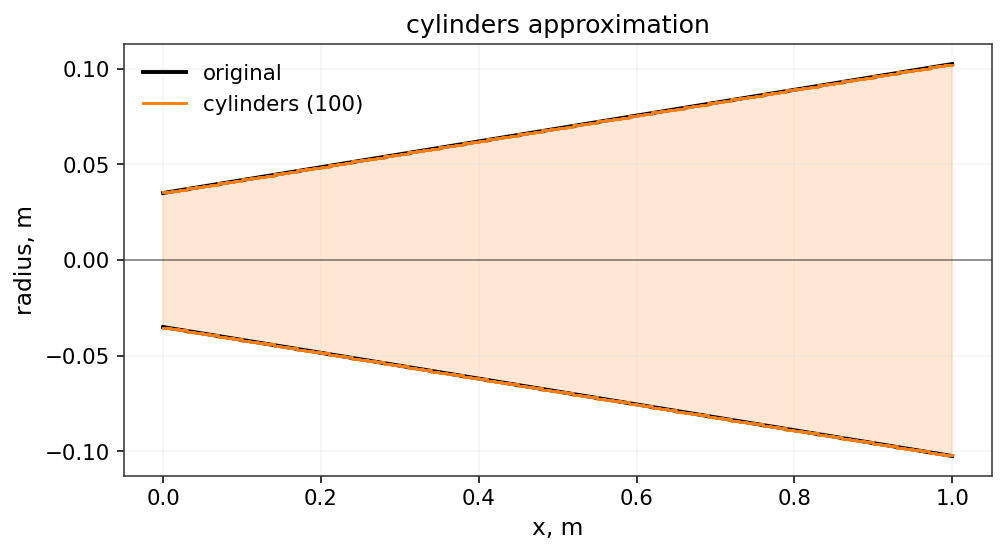

In [20]:
range_library = {
    "cylinder": {
        "length_m": 1.0,
        "area_m2": (1.0e-4, 3.0e-2),
    },

    "conical": {
        "length_m": 1.0,
        "area_in_m2": (1.0e-4, 8.0e-3),
        "area_out_m2": (2.0e-4, 5.0e-2),
    },

    "three_point": {
        "length_m": 1.0,
        "area_left_m2": (1.0e-4, 8.0e-3),
        "area_middle_m2": (2.0e-4, 4.0e-2),
        "area_right_m2": (1.0e-4, 2.0e-2),
    },

    "tube_with_hole": {
        "length_m": 1.0,
        "base_width_m": (0.015, 0.25),
        "random": True,
    },

    "random_smooth": {
        "length_m": 1.0,
        "dx_m": (0.01, 0.05),
        "area0_m2": (1.5e-4, 2.0e-2),
        "amp": (0.1, 0.45),
        "n_harmonics": (3, 6),
    },

    "random_piecewise": {
        "length_m": 1.0,
        "mean_width_m": (0.015, 0.25),
        "section_count": (4, 12),
        "width_spread": (0.05, 0.4),
    },
}

geom = vt.make_geometry_from_range_library(
    "conical",
    range_library,
    seed=12,
)

vt.plot_geometry_approximation(
    geom,
    section_count=100,
    approx="cylinders",
    mode="graph",
)

vt.plot_geometry_approximation(
    geom,
    section_count=100,
    approx="cylinders",
    mode="symmetric",
)

## 4. Сравнение качества апроксимации

In [21]:
import math
import statistics
import matplotlib.pyplot as plt
import vt_all_solvers_wrapper as vt
from base_range_library import range_library


def area_from_cylinder_sections(sections, x):
    for sec in sections:
        if sec["left_x_m"] <= x <= sec["right_x_m"]:
            return sec["area_m2"]
    if x < sections[0]["left_x_m"]:
        return sections[0]["area_m2"]
    return sections[-1]["area_m2"]


def area_from_cone_sections(sections, x):
    for sec in sections:
        x0 = sec["left_x_m"]
        x1 = sec["right_x_m"]
        if x0 <= x <= x1:
            if x1 == x0:
                return sec["area_in_m2"]
            t = (x - x0) / (x1 - x0)
            return sec["area_in_m2"] * (1.0 - t) + sec["area_out_m2"] * t
    if x < sections[0]["left_x_m"]:
        return sections[0]["area_in_m2"]
    return sections[-1]["area_out_m2"]


def mean_relative_area_error(original_geom, approx_kind="cylinders", section_count=24, n_eval=1000, eps=1e-12):
    x_nodes, area_nodes = vt.geometry_to_arrays(original_geom)
    x0 = x_nodes[0]
    x1 = x_nodes[-1]

    if approx_kind == "cylinders":
        sections = vt.approximate_with_cylinders(original_geom, section_count)
        approx_area_fn = lambda x: area_from_cylinder_sections(sections, x)
    elif approx_kind == "cones":
        sections = vt.approximate_with_cones(original_geom, section_count)
        approx_area_fn = lambda x: area_from_cone_sections(sections, x)
    else:
        raise ValueError("approx_kind must be 'cylinders' or 'cones'")

    rel_errors = []
    for i in range(n_eval):
        x = x0 + (x1 - x0) * i / (n_eval - 1)
        a_true = vt._area_at_linear_arrays(x_nodes, area_nodes, x)
        a_approx = approx_area_fn(x)
        rel_errors.append(abs(a_approx - a_true) / max(abs(a_true), eps))

    return sum(rel_errors) / len(rel_errors)


def compare_approximations_on_range_library(
    range_library,
    n_geometries=200,
    geometry_kind="random",
    section_count=24,
    n_eval=1000,
    seed0=1,
):
    rows = []

    for i in range(n_geometries):
        geom = vt.make_geometry_from_range_library(
            geometry_kind,
            range_library,
            seed=seed0 + i,
        )

        err_cyl = mean_relative_area_error(
            geom,
            approx_kind="cylinders",
            section_count=section_count,
            n_eval=n_eval,
        )
        err_cone = mean_relative_area_error(
            geom,
            approx_kind="cones",
            section_count=section_count,
            n_eval=n_eval,
        )

        rows.append(
            {
                "index": i,
                "geometry": geom,
                "err_cyl": err_cyl,
                "err_cone": err_cone,
                "winner": "cylinders" if err_cyl < err_cone else "cones",
            }
        )

    mean_cyl = statistics.mean(row["err_cyl"] for row in rows)
    mean_cone = statistics.mean(row["err_cone"] for row in rows)

    cyl_wins = sum(row["err_cyl"] < row["err_cone"] for row in rows)
    cone_wins = sum(row["err_cone"] < row["err_cyl"] for row in rows)
    ties = n_geometries - cyl_wins - cone_wins

    print(f"n_geometries = {n_geometries}")
    print(f"section_count = {section_count}")
    print(f"geometry_kind = {geometry_kind}")
    print()
    print(f"mean relative area error, cylinders = {100 * mean_cyl:.4f}%")
    print(f"mean relative area error, cones     = {100 * mean_cone:.4f}%")
    print()
    print(f"wins: cylinders = {cyl_wins}, cones = {cone_wins}, ties = {ties}")

    return rows

n_geometries = 1000
section_count = 100
geometry_kind = random

mean relative area error, cylinders = 2.3208%
mean relative area error, cones     = 3.3896%

wins: cylinders = 303, cones = 695, ties = 2


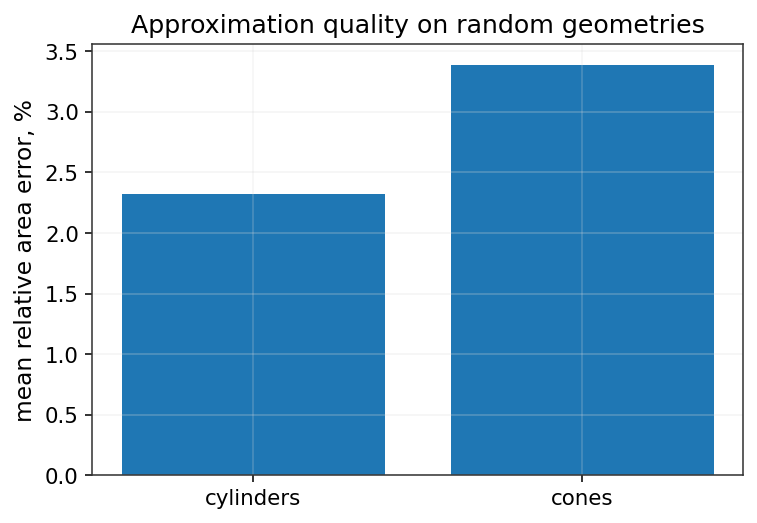

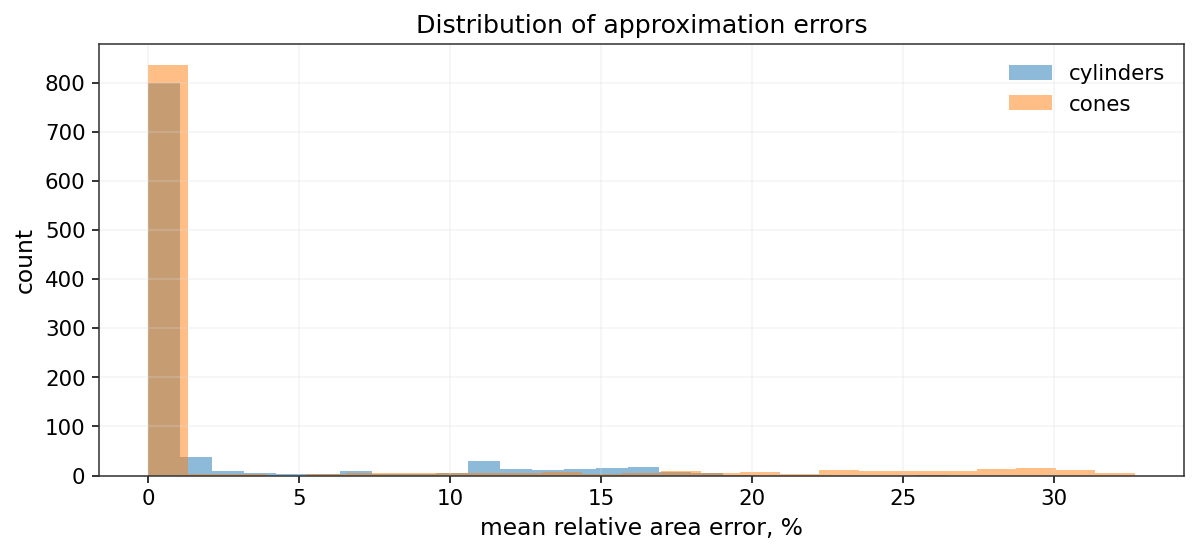

Worst for cylinders:
  cylinders err = 26.4440%
  cones err     = 7.7521%
Worst for cones:
  cones err     = 32.6688%
  cylinders err = 3.1156%


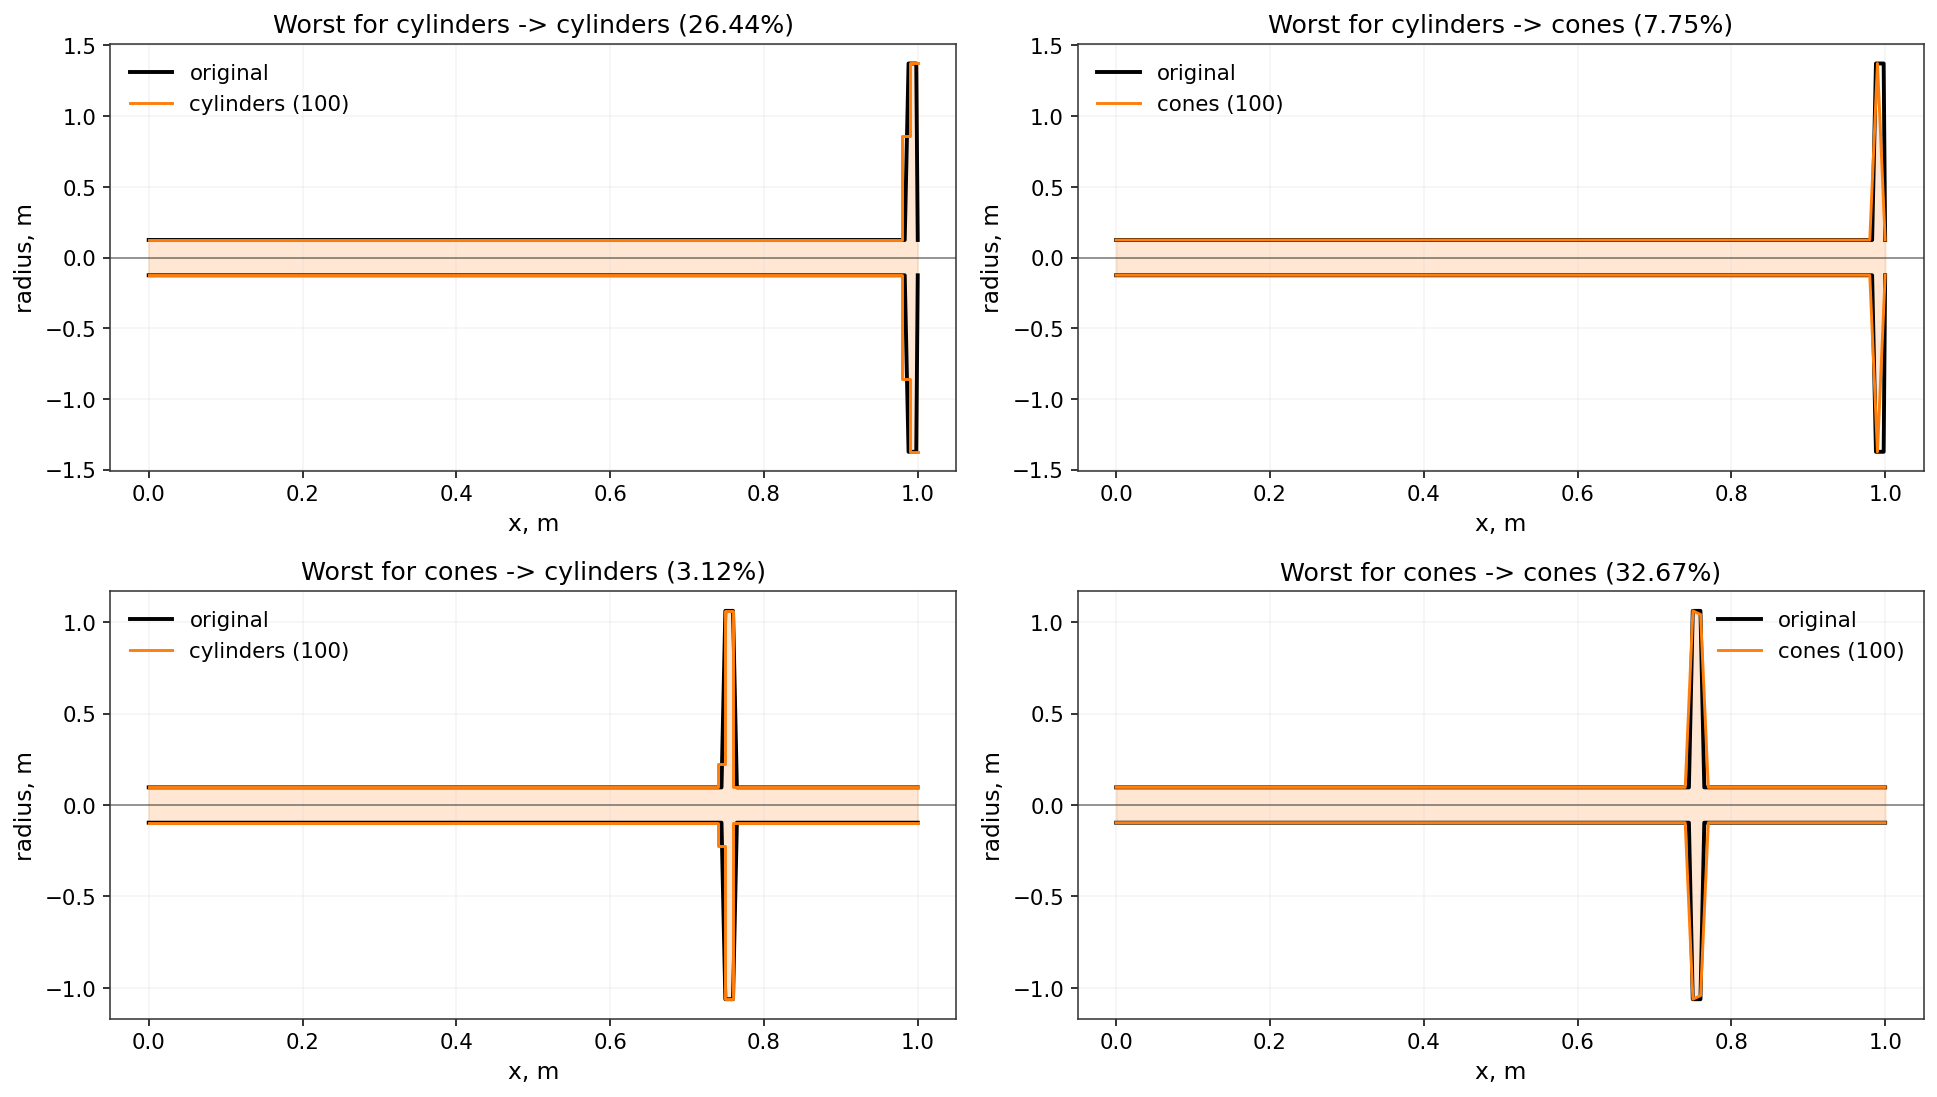

In [22]:
section_count = 100

rows = compare_approximations_on_range_library(
    range_library,
    n_geometries=1000,
    geometry_kind="random",
    section_count=section_count,
    n_eval=1000,
    seed0=1,
)

mean_cyl = statistics.mean(row["err_cyl"] for row in rows)
mean_cone = statistics.mean(row["err_cone"] for row in rows)

plt.figure(figsize=(6, 4))
plt.bar(["cylinders", "cones"], [100 * mean_cyl, 100 * mean_cone])
plt.ylabel("mean relative area error, %")
plt.title("Approximation quality on random geometries")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.hist([100 * row["err_cyl"] for row in rows], bins=25, alpha=0.5, label="cylinders")
plt.hist([100 * row["err_cone"] for row in rows], bins=25, alpha=0.5, label="cones")
plt.xlabel("mean relative area error, %")
plt.ylabel("count")
plt.title("Distribution of approximation errors")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

worst_cyl = max(rows, key=lambda row: row["err_cyl"])
worst_cone = max(rows, key=lambda row: row["err_cone"])

print("Worst for cylinders:")
print(f"  cylinders err = {100 * worst_cyl['err_cyl']:.4f}%")
print(f"  cones err     = {100 * worst_cyl['err_cone']:.4f}%")

print("Worst for cones:")
print(f"  cones err     = {100 * worst_cone['err_cone']:.4f}%")
print(f"  cylinders err = {100 * worst_cone['err_cyl']:.4f}%")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

vt.plot_geometry_approximation(
    worst_cyl["geometry"],
    section_count=section_count,
    approx="cylinders",
    mode="symmetric",
    ax=axes[0, 0],
    title=f"Worst for cylinders -> cylinders ({100 * worst_cyl['err_cyl']:.2f}%)",
)

vt.plot_geometry_approximation(
    worst_cyl["geometry"],
    section_count=section_count,
    approx="cones",
    mode="symmetric",
    ax=axes[0, 1],
    title=f"Worst for cylinders -> cones ({100 * worst_cyl['err_cone']:.2f}%)",
)

vt.plot_geometry_approximation(
    worst_cone["geometry"],
    section_count=section_count,
    approx="cylinders",
    mode="symmetric",
    ax=axes[1, 0],
    title=f"Worst for cones -> cylinders ({100 * worst_cone['err_cyl']:.2f}%)",
)

vt.plot_geometry_approximation(
    worst_cone["geometry"],
    section_count=section_count,
    approx="cones",
    mode="symmetric",
    ax=axes[1, 1],
    title=f"Worst for cones -> cones ({100 * worst_cone['err_cone']:.2f}%)",
)

plt.tight_layout()
plt.show()

## 5. Графики ошибки от количества секций

### Все каналы

In [14]:
import statistics
import matplotlib.pyplot as plt
import vt_all_solvers_wrapper as vt
from base_range_library import range_library


def area_from_cylinder_sections(sections, x):
    for sec in sections:
        if sec["left_x_m"] <= x <= sec["right_x_m"]:
            return sec["area_m2"]
    if x < sections[0]["left_x_m"]:
        return sections[0]["area_m2"]
    return sections[-1]["area_m2"]


def area_from_cone_sections(sections, x):
    for sec in sections:
        x0 = sec["left_x_m"]
        x1 = sec["right_x_m"]
        if x0 <= x <= x1:
            if x1 == x0:
                return sec["area_in_m2"]
            t = (x - x0) / (x1 - x0)
            return sec["area_in_m2"] * (1.0 - t) + sec["area_out_m2"] * t
    if x < sections[0]["left_x_m"]:
        return sections[0]["area_in_m2"]
    return sections[-1]["area_out_m2"]


def mean_relative_area_error(original_geom, approx_kind, section_count, n_eval=1000, eps=1e-12):
    x_nodes, area_nodes = vt.geometry_to_arrays(original_geom)
    x0 = x_nodes[0]
    x1 = x_nodes[-1]

    if approx_kind == "cylinders":
        sections = vt.approximate_with_cylinders(original_geom, section_count)
        approx_area_fn = lambda x: area_from_cylinder_sections(sections, x)
    elif approx_kind == "cones":
        sections = vt.approximate_with_cones(original_geom, section_count)
        approx_area_fn = lambda x: area_from_cone_sections(sections, x)
    else:
        raise ValueError("approx_kind must be 'cylinders' or 'cones'")

    rel_errors = []
    for i in range(n_eval):
        x = x0 + (x1 - x0) * i / (n_eval - 1)
        a_true = vt._area_at_linear_arrays(x_nodes, area_nodes, x)
        a_approx = approx_area_fn(x)
        rel_errors.append(abs(a_approx - a_true) / max(abs(a_true), eps))

    return sum(rel_errors) / len(rel_errors)


def compare_error_vs_sections(
    range_library,
    section_counts,
    n_geometries=100,
    geometry_kind="random",
    n_eval=1000,
    seed0=1,
):
    mean_err_cyl = []
    mean_err_cone = []

    for section_count in section_counts:
        errs_cyl = []
        errs_cone = []

        for i in range(n_geometries):
            geom = vt.make_geometry_from_range_library(
                geometry_kind,
                range_library,
                seed=seed0 + i,
            )

            errs_cyl.append(
                mean_relative_area_error(
                    geom,
                    approx_kind="cylinders",
                    section_count=section_count,
                    n_eval=n_eval,
                )
            )
            errs_cone.append(
                mean_relative_area_error(
                    geom,
                    approx_kind="cones",
                    section_count=section_count,
                    n_eval=n_eval,
                )
            )

        mean_err_cyl.append(statistics.mean(errs_cyl))
        mean_err_cone.append(statistics.mean(errs_cone))

    return mean_err_cyl, mean_err_cone

In [24]:
section_counts = [4, 8, 12, 16, 24, 32, 48, 64, 96, 128, 200]

mean_err_cyl, mean_err_cone = compare_error_vs_sections(
    range_library,
    section_counts,
    n_geometries=100,
    geometry_kind="random",
    n_eval=1000,
    seed0=1,
)

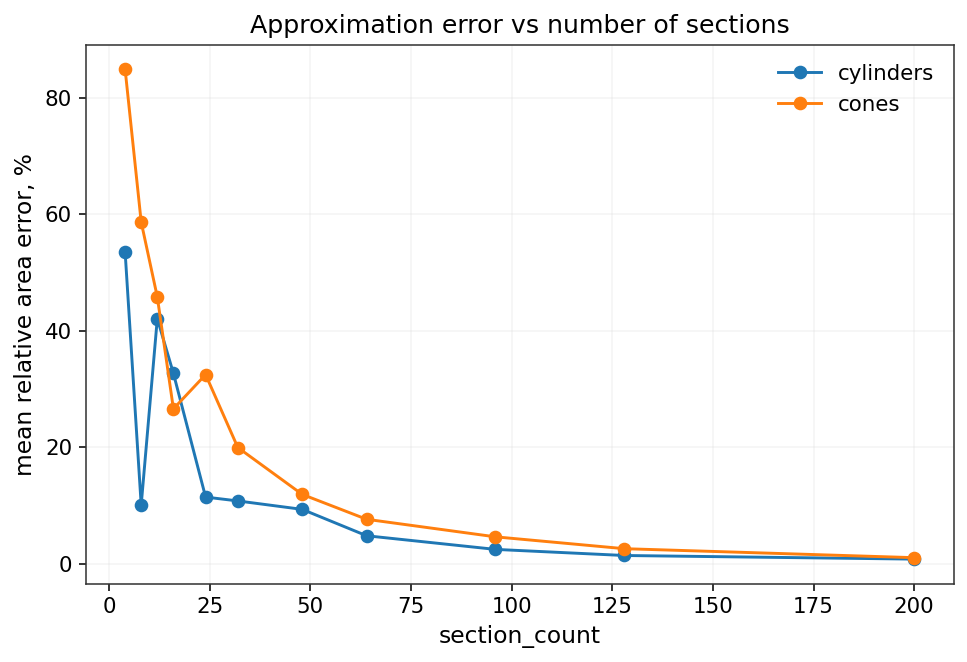

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(section_counts, [100 * e for e in mean_err_cyl], marker="o", label="cylinders")
plt.plot(section_counts, [100 * e for e in mean_err_cone], marker="o", label="cones")
plt.xlabel("section_count")
plt.ylabel("mean relative area error, %")
plt.title("Approximation error vs number of sections")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Дырки

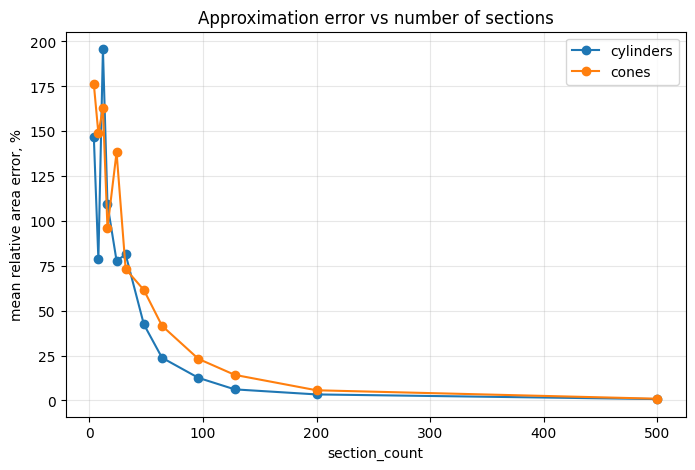

In [16]:
section_counts = [4, 8, 12, 16, 24, 32, 48, 64, 96, 128, 200]

mean_err_cyl, mean_err_cone = compare_error_vs_sections(
    range_library,
    section_counts,
    n_geometries=100,
    geometry_kind="tube_with_hole",
    n_eval=1000,
    seed0=1,
)

plt.figure(figsize=(8, 5))
plt.plot(section_counts, [100 * e for e in mean_err_cyl], marker="o", label="cylinders")
plt.plot(section_counts, [100 * e for e in mean_err_cone], marker="o", label="cones")
plt.xlabel("section_count")
plt.ylabel("mean relative area error, %")
plt.title("Approximation error vs number of sections")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 6. Сравнение скорости классики и нейросетей

### По частоте

Building solver binary...
Generating geometries...
Device: cpu
Geometries: 100
MLP input shape: (100, 100, 2)
FNO/DeepONet area shape: (100, 1, 100)
Model batch size: 64

points = 32
cone:      23.5101 ms/sample
MLP:       0.040995 ms/sample, speedup 573.48x
FNO:       0.846828 ms/sample, speedup 27.76x
DeepONet:  0.367724 ms/sample, speedup 63.93x

points = 64
cone:      25.3143 ms/sample
MLP:       0.039148 ms/sample, speedup 646.64x
FNO:       0.838355 ms/sample, speedup 30.20x
DeepONet:  0.371208 ms/sample, speedup 68.19x

points = 128
cone:      27.4570 ms/sample
MLP:       0.027365 ms/sample, speedup 1003.37x
FNO:       1.125060 ms/sample, speedup 24.40x
DeepONet:  0.439916 ms/sample, speedup 62.41x

points = 256
cone:      30.6096 ms/sample
MLP:       0.028427 ms/sample, speedup 1076.79x
FNO:       1.628475 ms/sample, speedup 18.80x
DeepONet:  0.602072 ms/sample, speedup 50.84x

points = 512
cone:      37.9215 ms/sample
MLP:       0.039906 ms/sample, speedup 950.28x
FNO:       3

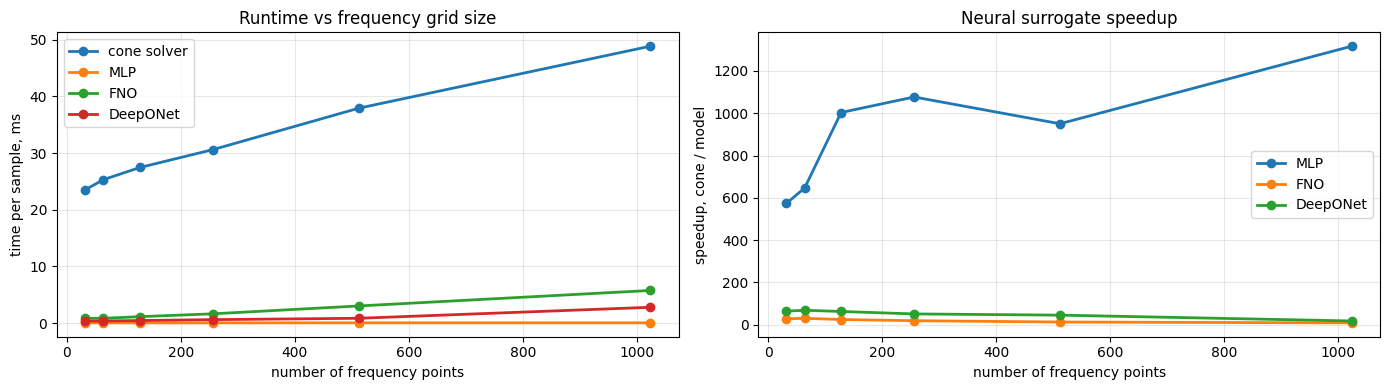

In [11]:
import importlib
import time

import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.nn.utils.rnn import pad_sequence

import vt_all_solvers_wrapper as vt
import utils
import models.mlp as mlp_module
import models.fno as fno_module
import models.deep as deep_module

importlib.reload(vt)
importlib.reload(utils)
importlib.reload(mlp_module)
importlib.reload(fno_module)
importlib.reload(deep_module)

from base_range_library import range_library
from models.mlp import ProfileMLP
from models.fno import TransferFunctionFNO
from models.deep import TransferFunctionDeepONet


# -------------------------
# Config
# -------------------------

device = "cpu"  # поставь "cuda", если хочешь GPU benchmark

geometry_kind = "random"
seed = 123

n_samples = 100
sections = 100
n_profile_points = sections

points_list = [32, 64, 128, 256, 512, 1024]

model_batch_size = 64  # throughput режим; для latency поставь 1
warmup_runs = 10
measured_repeats = 5

f_min_hz = 50.0
f_max_hz = 5000.0

mlp_hidden_dim = 512
mlp_depth = 4
mlp_dropout = 0.05

fno_n_modes = 32
fno_hidden_channels = 96
fno_latent_dim = 256
fno_pooling_bins = 16
fno_frequency_bands = 16

deeponet_hidden_channels = 64
deeponet_basis_dim = 128
deeponet_pooling_bins = 16
deeponet_frequency_bands = 16
deeponet_trunk_hidden_dim = 128


# -------------------------
# Helpers
# -------------------------

def sync_device():
    if torch.cuda.is_available() and torch.device(device).type == "cuda":
        torch.cuda.synchronize()


def geometries_to_batch(geometries):
    xs = []
    areas = []
    seg_lengths = []

    for geometry in geometries:
        x_m, area_m2, segment_lengths_m = vt.geometry_to_tube_tuple(geometry)

        xs.append(torch.tensor(x_m, dtype=torch.float32))
        areas.append(torch.tensor(area_m2, dtype=torch.float32))
        seg_lengths.append(torch.tensor(segment_lengths_m, dtype=torch.float32))

    return {
        "geometry": {
            "x_m": pad_sequence(xs, batch_first=True),
            "area_m2": pad_sequence(areas, batch_first=True),
            "segment_lengths_m": pad_sequence(seg_lengths, batch_first=True),
            "node_count": torch.tensor([len(x) for x in xs], dtype=torch.int64),
            "segment_count": torch.tensor([len(s) for s in seg_lengths], dtype=torch.int64),
        }
    }


def make_kappa(batch_size, points):
    frequencies = torch.linspace(
        f_min_hz,
        f_max_hz,
        points,
        device=device,
        dtype=torch.float32,
    ).unsqueeze(0).expand(batch_size, -1)

    kappa = (
        (frequencies - f_min_hz)
        / max(f_max_hz - f_min_hz, 1e-12)
    ).unsqueeze(-1)

    return kappa


def benchmark_cone_for_points(geometries, points):
    config = vt.SolverConfig(
        solver="cone",
        sections=sections,
        points=points,
        f_min_hz=f_min_hz,
        f_max_hz=f_max_hz,
        grid="linear",
        beta_loss_np_per_m=0.0,
    )

    t0 = time.perf_counter()

    for geometry in geometries:
        _ = vt.solve(
            geometry=geometry,
            config=config,
            rebuild=False,
        )

    return time.perf_counter() - t0


@torch.inference_mode()
def benchmark_model(model, inputs, n_samples):
    model = model.to(device)
    model.eval()

    first = inputs[0] if isinstance(inputs, tuple) else inputs
    batch_count = first.shape[0]

    for _ in range(warmup_runs):
        for start in range(0, batch_count, model_batch_size):
            sliced = tuple(x[start:start + model_batch_size] for x in inputs) if isinstance(inputs, tuple) else inputs[start:start + model_batch_size]
            if isinstance(sliced, tuple):
                _ = model(*sliced)
            else:
                _ = model(sliced)

    sync_device()
    repeat_times = []

    for _ in range(measured_repeats):
        sync_device()
        t0 = time.perf_counter()

        for start in range(0, batch_count, model_batch_size):
            sliced = tuple(x[start:start + model_batch_size] for x in inputs) if isinstance(inputs, tuple) else inputs[start:start + model_batch_size]
            if isinstance(sliced, tuple):
                _ = model(*sliced)
            else:
                _ = model(sliced)

        sync_device()
        repeat_times.append(time.perf_counter() - t0)

    return float(np.mean(repeat_times))


def make_models_for_points(points):
    mlp = ProfileMLP(
        n_profile_points=n_profile_points,
        in_channels=2,
        n_frequencies=points,
        hidden_dim=mlp_hidden_dim,
        depth=mlp_depth,
        dropout=mlp_dropout,
        out_channels=1,
    )

    fno = TransferFunctionFNO(
        n_modes=min(fno_n_modes, max(1, n_profile_points // 2)),
        hidden_channels=fno_hidden_channels,
        latent_dim=fno_latent_dim,
        pooling_bins=min(fno_pooling_bins, n_profile_points),
        frequency_bands=fno_frequency_bands,
        out_channels=1,
    )

    deeponet = TransferFunctionDeepONet(
        in_channels=1,
        hidden_channels=deeponet_hidden_channels,
        basis_dim=deeponet_basis_dim,
        pooling_bins=min(deeponet_pooling_bins, n_profile_points),
        frequency_bands=deeponet_frequency_bands,
        trunk_hidden_dim=deeponet_trunk_hidden_dim,
        out_channels=1,
    )

    return mlp, fno, deeponet


# -------------------------
# Prepare data
# -------------------------

print("Building solver binary...")
vt.build_binary(rebuild=False)

print("Generating geometries...")
geometries = [
    vt.make_geometry_from_range_library(
        geometry_kind,
        range_library,
        seed=seed + i,
    )
    for i in range(n_samples)
]

raw_batch = geometries_to_batch(geometries)

profile_mlp = utils.make_webster_profile_features(
    raw_batch,
    n_points=n_profile_points,
    log_area=True,
    include_x=True,
    channel_first=False,
    device=device,
)

profile_operator = utils.make_webster_profile_features(
    raw_batch,
    n_points=n_profile_points,
    log_area=True,
    include_x=False,
    channel_first=True,
    device=device,
)

print("Device:", device)
print("Geometries:", len(geometries))
print("MLP input shape:", tuple(profile_mlp.shape))
print("FNO/DeepONet area shape:", tuple(profile_operator.shape))
print("Model batch size:", model_batch_size)


# -------------------------
# Run benchmark
# -------------------------

results = []

for points in points_list:
    print(f"\npoints = {points}")

    kappa = make_kappa(n_samples, points)
    mlp, fno, deeponet = make_models_for_points(points)

    cone_time_s = benchmark_cone_for_points(geometries, points)
    mlp_time_s = benchmark_model(mlp, profile_mlp, n_samples)
    fno_time_s = benchmark_model(fno, (profile_operator, kappa), n_samples)
    deeponet_time_s = benchmark_model(deeponet, (profile_operator, kappa), n_samples)

    row = {
        "points": points,
        "cone_ms_per_sample": cone_time_s / n_samples * 1000.0,
        "mlp_ms_per_sample": mlp_time_s / n_samples * 1000.0,
        "fno_ms_per_sample": fno_time_s / n_samples * 1000.0,
        "deeponet_ms_per_sample": deeponet_time_s / n_samples * 1000.0,
        "mlp_speedup": cone_time_s / mlp_time_s,
        "fno_speedup": cone_time_s / fno_time_s,
        "deeponet_speedup": cone_time_s / deeponet_time_s,
    }
    results.append(row)

    print(f"cone:      {row['cone_ms_per_sample']:.4f} ms/sample")
    print(f"MLP:       {row['mlp_ms_per_sample']:.6f} ms/sample, speedup {row['mlp_speedup']:.2f}x")
    print(f"FNO:       {row['fno_ms_per_sample']:.6f} ms/sample, speedup {row['fno_speedup']:.2f}x")
    print(f"DeepONet:  {row['deeponet_ms_per_sample']:.6f} ms/sample, speedup {row['deeponet_speedup']:.2f}x")


# -------------------------
# Print table
# -------------------------

print("\n=== Results: runtime vs frequency grid size ===")
print(
    f"{'points':>8} | "
    f"{'cone':>12} | "
    f"{'MLP':>12} | "
    f"{'FNO':>12} | "
    f"{'DeepONet':>12} | "
    f"{'MLP x':>8} | "
    f"{'FNO x':>8} | "
    f"{'Deep x':>8}"
)
print("-" * 100)

for row in results:
    print(
        f"{row['points']:8d} | "
        f"{row['cone_ms_per_sample']:12.4f} | "
        f"{row['mlp_ms_per_sample']:12.6f} | "
        f"{row['fno_ms_per_sample']:12.6f} | "
        f"{row['deeponet_ms_per_sample']:12.6f} | "
        f"{row['mlp_speedup']:8.2f} | "
        f"{row['fno_speedup']:8.2f} | "
        f"{row['deeponet_speedup']:8.2f}"
    )


# -------------------------
# Plot
# -------------------------

points = np.array([row["points"] for row in results])
cone_ms = np.array([row["cone_ms_per_sample"] for row in results])
mlp_ms = np.array([row["mlp_ms_per_sample"] for row in results])
fno_ms = np.array([row["fno_ms_per_sample"] for row in results])
deeponet_ms = np.array([row["deeponet_ms_per_sample"] for row in results])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(points, cone_ms, marker="o", linewidth=2, label="cone solver")
axes[0].plot(points, mlp_ms, marker="o", linewidth=2, label="MLP")
axes[0].plot(points, fno_ms, marker="o", linewidth=2, label="FNO")
axes[0].plot(points, deeponet_ms, marker="o", linewidth=2, label="DeepONet")
axes[0].set_xlabel("number of frequency points")
axes[0].set_ylabel("time per sample, ms")
axes[0].set_title("Runtime vs frequency grid size")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(points, [row["mlp_speedup"] for row in results], marker="o", linewidth=2, label="MLP")
axes[1].plot(points, [row["fno_speedup"] for row in results], marker="o", linewidth=2, label="FNO")
axes[1].plot(points, [row["deeponet_speedup"] for row in results], marker="o", linewidth=2, label="DeepONet")
axes[1].set_xlabel("number of frequency points")
axes[1].set_ylabel("speedup, cone / model")
axes[1].set_title("Neural surrogate speedup")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### Дискретизация канала

Building solver binary...
Generating geometries...
Device: cpu
Geometries: 100
Frequencies: 256
Model batch size: 1

discretization points = 64
MLP input shape: (100, 64, 2)
FNO/DeepONet area shape: (100, 1, 64)
cone:      33.8694 ms/sample
MLP:       0.557560 ms/sample, speedup 60.75x
FNO:       7.576261 ms/sample, speedup 4.47x
DeepONet:  4.152923 ms/sample, speedup 8.16x

discretization points = 128
MLP input shape: (100, 128, 2)
FNO/DeepONet area shape: (100, 1, 128)
cone:      37.8638 ms/sample
MLP:       0.463593 ms/sample, speedup 81.67x
FNO:       8.421867 ms/sample, speedup 4.50x
DeepONet:  4.557252 ms/sample, speedup 8.31x

discretization points = 256
MLP input shape: (100, 256, 2)
FNO/DeepONet area shape: (100, 1, 256)
cone:      39.5157 ms/sample
MLP:       0.553580 ms/sample, speedup 71.38x
FNO:       10.501423 ms/sample, speedup 3.76x
DeepONet:  6.008020 ms/sample, speedup 6.58x

discretization points = 512
MLP input shape: (100, 512, 2)
FNO/DeepONet area shape: (100, 1, 

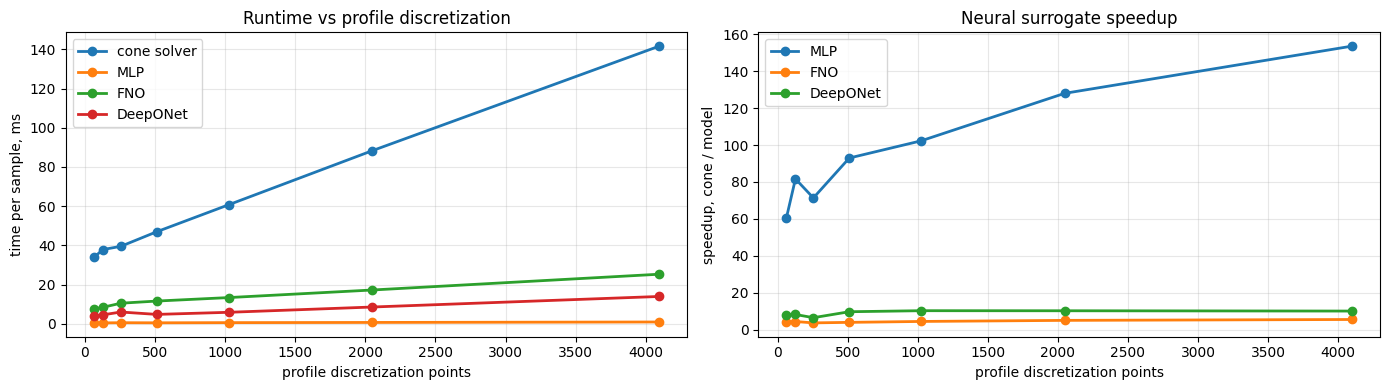

In [12]:
import importlib
import time

import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.nn.utils.rnn import pad_sequence

import vt_all_solvers_wrapper as vt
import utils
import models.mlp as mlp_module
import models.fno as fno_module
import models.deep as deep_module

importlib.reload(vt)
importlib.reload(utils)
importlib.reload(mlp_module)
importlib.reload(fno_module)
importlib.reload(deep_module)

from base_range_library import range_library
from models.mlp import ProfileMLP
from models.fno import TransferFunctionFNO
from models.deep import TransferFunctionDeepONet


# -------------------------
# Config
# -------------------------

device = "cpu"  # поставь "cuda", если хочешь GPU benchmark

geometry_kind = "random"
seed = 123

n_samples = 100
n_frequencies = 256

discretization_list = [64, 128, 256, 512, 1024, 2048, 4096]

model_batch_size = 1  # latency режим: один канал за forward-pass
warmup_runs = 10
measured_repeats = 5

f_min_hz = 50.0
f_max_hz = 5000.0

mlp_hidden_dim = 512
mlp_depth = 4
mlp_dropout = 0.05

fno_n_modes = 32
fno_hidden_channels = 96
fno_latent_dim = 256
fno_pooling_bins = 16
fno_frequency_bands = 16

deeponet_hidden_channels = 64
deeponet_basis_dim = 128
deeponet_pooling_bins = 16
deeponet_frequency_bands = 16
deeponet_trunk_hidden_dim = 128


# -------------------------
# Helpers
# -------------------------

def sync_device():
    if torch.cuda.is_available() and torch.device(device).type == "cuda":
        torch.cuda.synchronize()


def geometries_to_batch(geometries):
    xs = []
    areas = []
    seg_lengths = []

    for geometry in geometries:
        x_m, area_m2, segment_lengths_m = vt.geometry_to_tube_tuple(geometry)

        xs.append(torch.tensor(x_m, dtype=torch.float32))
        areas.append(torch.tensor(area_m2, dtype=torch.float32))
        seg_lengths.append(torch.tensor(segment_lengths_m, dtype=torch.float32))

    return {
        "geometry": {
            "x_m": pad_sequence(xs, batch_first=True),
            "area_m2": pad_sequence(areas, batch_first=True),
            "segment_lengths_m": pad_sequence(seg_lengths, batch_first=True),
            "node_count": torch.tensor([len(x) for x in xs], dtype=torch.int64),
            "segment_count": torch.tensor([len(s) for s in seg_lengths], dtype=torch.int64),
        }
    }


def make_kappa(batch_size):
    frequencies = torch.linspace(
        f_min_hz,
        f_max_hz,
        n_frequencies,
        device=device,
        dtype=torch.float32,
    ).unsqueeze(0).expand(batch_size, -1)

    kappa = (
        (frequencies - f_min_hz)
        / max(f_max_hz - f_min_hz, 1e-12)
    ).unsqueeze(-1)

    return kappa


def benchmark_cone_for_discretization(geometries, n_points):
    config = vt.SolverConfig(
        solver="cone",
        sections=n_points,
        points=n_frequencies,
        f_min_hz=f_min_hz,
        f_max_hz=f_max_hz,
        grid="linear",
        beta_loss_np_per_m=0.0,
    )

    t0 = time.perf_counter()

    for geometry in geometries:
        _ = vt.solve(
            geometry=geometry,
            config=config,
            rebuild=False,
        )

    return time.perf_counter() - t0


@torch.inference_mode()
def benchmark_model(model, inputs, n_samples):
    model = model.to(device)
    model.eval()

    first = inputs[0] if isinstance(inputs, tuple) else inputs
    batch_count = first.shape[0]

    for _ in range(warmup_runs):
        for start in range(0, batch_count, model_batch_size):
            sliced = tuple(x[start:start + model_batch_size] for x in inputs) if isinstance(inputs, tuple) else inputs[start:start + model_batch_size]
            if isinstance(sliced, tuple):
                _ = model(*sliced)
            else:
                _ = model(sliced)

    sync_device()
    repeat_times = []

    for _ in range(measured_repeats):
        sync_device()
        t0 = time.perf_counter()

        for start in range(0, batch_count, model_batch_size):
            sliced = tuple(x[start:start + model_batch_size] for x in inputs) if isinstance(inputs, tuple) else inputs[start:start + model_batch_size]
            if isinstance(sliced, tuple):
                _ = model(*sliced)
            else:
                _ = model(sliced)

        sync_device()
        repeat_times.append(time.perf_counter() - t0)

    return float(np.mean(repeat_times))


def make_models_for_discretization(n_points):
    mlp = ProfileMLP(
        n_profile_points=n_points,
        in_channels=2,
        n_frequencies=n_frequencies,
        hidden_dim=mlp_hidden_dim,
        depth=mlp_depth,
        dropout=mlp_dropout,
        out_channels=1,
    )

    fno = TransferFunctionFNO(
        n_modes=min(fno_n_modes, max(1, n_points // 2)),
        hidden_channels=fno_hidden_channels,
        latent_dim=fno_latent_dim,
        pooling_bins=min(fno_pooling_bins, n_points),
        frequency_bands=fno_frequency_bands,
        out_channels=1,
    )

    deeponet = TransferFunctionDeepONet(
        in_channels=1,
        hidden_channels=deeponet_hidden_channels,
        basis_dim=deeponet_basis_dim,
        pooling_bins=min(deeponet_pooling_bins, n_points),
        frequency_bands=deeponet_frequency_bands,
        trunk_hidden_dim=deeponet_trunk_hidden_dim,
        out_channels=1,
    )

    return mlp, fno, deeponet


def make_model_inputs(raw_batch, n_points):
    profile_mlp = utils.make_webster_profile_features(
        raw_batch,
        n_points=n_points,
        log_area=True,
        include_x=True,
        channel_first=False,
        device=device,
    )

    profile_operator = utils.make_webster_profile_features(
        raw_batch,
        n_points=n_points,
        log_area=True,
        include_x=False,
        channel_first=True,
        device=device,
    )

    kappa = make_kappa(profile_operator.shape[0])
    return profile_mlp, profile_operator, kappa


# -------------------------
# Prepare data
# -------------------------

print("Building solver binary...")
vt.build_binary(rebuild=False)

print("Generating geometries...")
geometries = [
    vt.make_geometry_from_range_library(
        geometry_kind,
        range_library,
        seed=seed + i,
    )
    for i in range(n_samples)
]

raw_batch = geometries_to_batch(geometries)

print("Device:", device)
print("Geometries:", len(geometries))
print("Frequencies:", n_frequencies)
print("Model batch size:", model_batch_size)


# -------------------------
# Run benchmark
# -------------------------

results = []

for n_points in discretization_list:
    print(f"\ndiscretization points = {n_points}")

    profile_mlp, profile_operator, kappa = make_model_inputs(raw_batch, n_points)
    mlp, fno, deeponet = make_models_for_discretization(n_points)

    cone_time_s = benchmark_cone_for_discretization(geometries, n_points)
    mlp_time_s = benchmark_model(mlp, profile_mlp, n_samples)
    fno_time_s = benchmark_model(fno, (profile_operator, kappa), n_samples)
    deeponet_time_s = benchmark_model(deeponet, (profile_operator, kappa), n_samples)

    row = {
        "n_points": n_points,
        "cone_ms_per_sample": cone_time_s / n_samples * 1000.0,
        "mlp_ms_per_sample": mlp_time_s / n_samples * 1000.0,
        "fno_ms_per_sample": fno_time_s / n_samples * 1000.0,
        "deeponet_ms_per_sample": deeponet_time_s / n_samples * 1000.0,
        "mlp_speedup": cone_time_s / mlp_time_s,
        "fno_speedup": cone_time_s / fno_time_s,
        "deeponet_speedup": cone_time_s / deeponet_time_s,
        "mlp_input_shape": tuple(profile_mlp.shape),
        "operator_input_shape": tuple(profile_operator.shape),
    }
    results.append(row)

    print("MLP input shape:", row["mlp_input_shape"])
    print("FNO/DeepONet area shape:", row["operator_input_shape"])
    print(f"cone:      {row['cone_ms_per_sample']:.4f} ms/sample")
    print(f"MLP:       {row['mlp_ms_per_sample']:.6f} ms/sample, speedup {row['mlp_speedup']:.2f}x")
    print(f"FNO:       {row['fno_ms_per_sample']:.6f} ms/sample, speedup {row['fno_speedup']:.2f}x")
    print(f"DeepONet:  {row['deeponet_ms_per_sample']:.6f} ms/sample, speedup {row['deeponet_speedup']:.2f}x")


# -------------------------
# Print table
# -------------------------

print("\n=== Results: runtime vs profile discretization ===")
print(
    f"{'points':>8} | "
    f"{'cone':>12} | "
    f"{'MLP':>12} | "
    f"{'FNO':>12} | "
    f"{'DeepONet':>12} | "
    f"{'MLP x':>8} | "
    f"{'FNO x':>8} | "
    f"{'Deep x':>8}"
)
print("-" * 100)

for row in results:
    print(
        f"{row['n_points']:8d} | "
        f"{row['cone_ms_per_sample']:12.4f} | "
        f"{row['mlp_ms_per_sample']:12.6f} | "
        f"{row['fno_ms_per_sample']:12.6f} | "
        f"{row['deeponet_ms_per_sample']:12.6f} | "
        f"{row['mlp_speedup']:8.2f} | "
        f"{row['fno_speedup']:8.2f} | "
        f"{row['deeponet_speedup']:8.2f}"
    )


# -------------------------
# Plot
# -------------------------

n_points = np.array([row["n_points"] for row in results])
cone_ms = np.array([row["cone_ms_per_sample"] for row in results])
mlp_ms = np.array([row["mlp_ms_per_sample"] for row in results])
fno_ms = np.array([row["fno_ms_per_sample"] for row in results])
deeponet_ms = np.array([row["deeponet_ms_per_sample"] for row in results])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(n_points, cone_ms, marker="o", linewidth=2, label="cone solver")
axes[0].plot(n_points, mlp_ms, marker="o", linewidth=2, label="MLP")
axes[0].plot(n_points, fno_ms, marker="o", linewidth=2, label="FNO")
axes[0].plot(n_points, deeponet_ms, marker="o", linewidth=2, label="DeepONet")
axes[0].set_xlabel("profile discretization points")
axes[0].set_ylabel("time per sample, ms")
axes[0].set_title("Runtime vs profile discretization")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(n_points, [row["mlp_speedup"] for row in results], marker="o", linewidth=2, label="MLP")
axes[1].plot(n_points, [row["fno_speedup"] for row in results], marker="o", linewidth=2, label="FNO")
axes[1].plot(n_points, [row["deeponet_speedup"] for row in results], marker="o", linewidth=2, label="DeepONet")
axes[1].set_xlabel("profile discretization points")
axes[1].set_ylabel("speedup, cone / model")
axes[1].set_title("Neural surrogate speedup")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## Скейлинг по площади

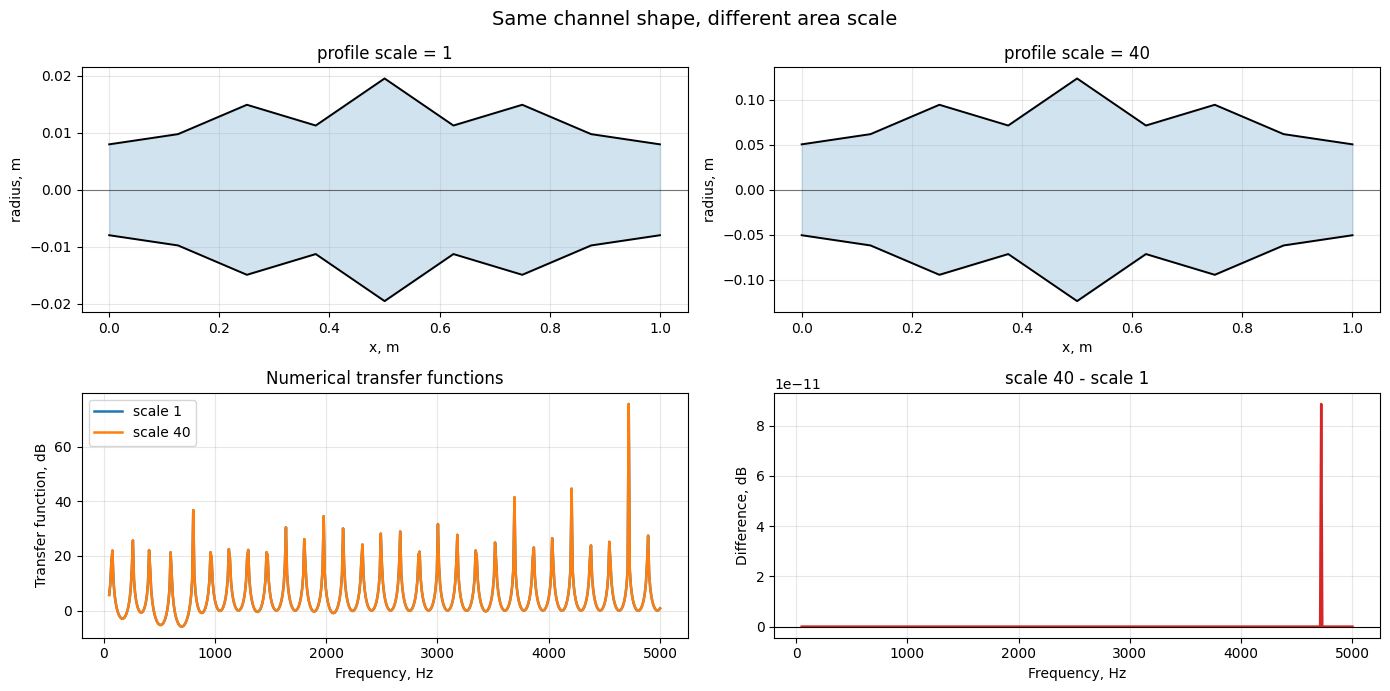

geometry 1 area min/max: 0.0002 0.0012
geometry 2 area min/max: 0.008 0.047999999999999994
mean abs dB difference: 1.7319479184152442e-13


In [6]:
import numpy as np
import matplotlib.pyplot as plt

import vt_all_solvers_wrapper as vt


# Same profile shape, different area scale.
length_m = 1.0
area_scale_1 = 1.0
area_scale_2 = 40.0

x_m = np.linspace(0.0, length_m, 9)

base_area_m2 = np.array(
    [
        2.0e-4,
        3.0e-4,
        7.0e-4,
        4.0e-4,
        1.2e-3,
        4.0e-4,
        7.0e-4,
        3.0e-4,
        2.0e-4,
    ],
    dtype=float,
)

geometry_1 = vt.ExplicitGeometry(
    x_m=x_m.tolist(),
    area_m2=(area_scale_1 * base_area_m2).tolist(),
)

geometry_2 = vt.ExplicitGeometry(
    x_m=x_m.tolist(),
    area_m2=(area_scale_2 * base_area_m2).tolist(),
)

solver_config = vt.SolverConfig(
    solver="cone",
    sections=100,
    points=512,
    f_min_hz=50.0,
    f_max_hz=5000.0,
    grid="linear",
    beta_loss_np_per_m=0.0,
)

result_1 = vt.solve(geometry_1, config=solver_config)
result_2 = vt.solve(geometry_2, config=solver_config)

freq_1 = np.asarray(result_1.frequencies_hz)
freq_2 = np.asarray(result_2.frequencies_hz)

mag_db_1 = 20.0 * np.log10(np.maximum(np.asarray(result_1.magnitude), 1e-12))
mag_db_2 = 20.0 * np.log10(np.maximum(np.asarray(result_2.magnitude), 1e-12))

fig, axes = plt.subplots(2, 2, figsize=(14, 7))

vt.plot_geometry(
    geometry_1,
    mode="symmetric",
    equal_aspect=False,
    linewidth=1.4,
    ax=axes[0, 0],
    title=f"profile scale = {area_scale_1:g}",
)
axes[0, 0].grid(True, alpha=0.3)

vt.plot_geometry(
    geometry_2,
    mode="symmetric",
    equal_aspect=False,
    linewidth=1.4,
    ax=axes[0, 1],
    title=f"profile scale = {area_scale_2:g}",
)
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(freq_1, mag_db_1, linewidth=1.8, label=f"scale {area_scale_1:g}")
axes[1, 0].plot(freq_2, mag_db_2, linewidth=1.8, label=f"scale {area_scale_2:g}")
axes[1, 0].set_xlabel("Frequency, Hz")
axes[1, 0].set_ylabel("Transfer function, dB")
axes[1, 0].set_title("Numerical transfer functions")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].plot(freq_1, mag_db_2 - mag_db_1, linewidth=1.8, color="tab:red")
axes[1, 1].axhline(0.0, color="black", linewidth=0.8)
axes[1, 1].set_xlabel("Frequency, Hz")
axes[1, 1].set_ylabel("Difference, dB")
axes[1, 1].set_title(f"scale {area_scale_2:g} - scale {area_scale_1:g}")
axes[1, 1].grid(True, alpha=0.3)

fig.suptitle("Same channel shape, different area scale", fontsize=14)
fig.tight_layout()
plt.show()

print("geometry 1 area min/max:", geometry_1.area_m2[0], max(geometry_1.area_m2))
print("geometry 2 area min/max:", geometry_2.area_m2[0], max(geometry_2.area_m2))
print("mean abs dB difference:", np.mean(np.abs(mag_db_2 - mag_db_1)))

## Полный скейлинг

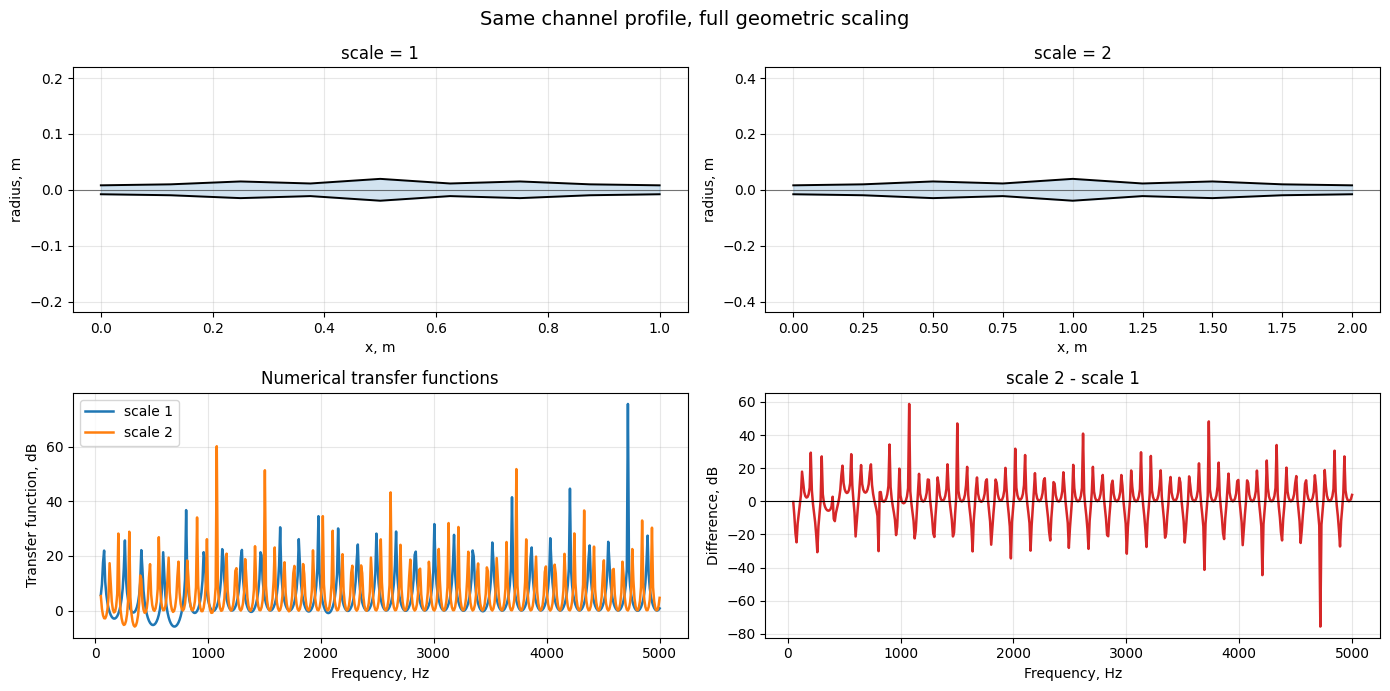

length 1: 1.0 m
length 2: 2.0 m
area scale 1: 1.0
area scale 2: 4
area min/max 1: 0.0002 0.0012
area min/max 2: 0.0008 0.0048
mean abs dB difference: 8.525225887738657


In [8]:
import numpy as np
import matplotlib.pyplot as plt

import vt_all_solvers_wrapper as vt


# Same dimensionless profile, different full geometric scale.
# length scale changes x, area scale changes area.
length_scale_1 = 1.0
length_scale_2 = 2

area_scale_1 = length_scale_1 ** 2
area_scale_2 = length_scale_2 ** 2

base_length_m = 1.0

x_norm = np.linspace(0.0, 1.0, 9)

base_area_m2 = np.array(
    [
        2.0e-4,
        3.0e-4,
        7.0e-4,
        4.0e-4,
        1.2e-3,
        4.0e-4,
        7.0e-4,
        3.0e-4,
        2.0e-4,
    ],
    dtype=float,
)

geometry_1 = vt.ExplicitGeometry(
    x_m=(length_scale_1 * base_length_m * x_norm).tolist(),
    area_m2=(area_scale_1 * base_area_m2).tolist(),
)

geometry_2 = vt.ExplicitGeometry(
    x_m=(length_scale_2 * base_length_m * x_norm).tolist(),
    area_m2=(area_scale_2 * base_area_m2).tolist(),
)

solver_config = vt.SolverConfig(
    solver="cone",
    sections=100,
    points=512,
    f_min_hz=50.0,
    f_max_hz=5000.0,
    grid="linear",
    beta_loss_np_per_m=0.0,
)

result_1 = vt.solve(geometry_1, config=solver_config)
result_2 = vt.solve(geometry_2, config=solver_config)

freq_1 = np.asarray(result_1.frequencies_hz)
freq_2 = np.asarray(result_2.frequencies_hz)

mag_db_1 = 20.0 * np.log10(np.maximum(np.asarray(result_1.magnitude), 1e-12))
mag_db_2 = 20.0 * np.log10(np.maximum(np.asarray(result_2.magnitude), 1e-12))

fig, axes = plt.subplots(2, 2, figsize=(14, 7))

vt.plot_geometry(
    geometry_1,
    mode="symmetric",
    equal_aspect=True,
    linewidth=1.4,
    ax=axes[0, 0],
    title=f"scale = {length_scale_1:g}",
)
axes[0, 0].grid(True, alpha=0.3)

vt.plot_geometry(
    geometry_2,
    mode="symmetric",
    equal_aspect=True,
    linewidth=1.4,
    ax=axes[0, 1],
    title=f"scale = {length_scale_2:g}",
)
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(freq_1, mag_db_1, linewidth=1.8, label=f"scale {length_scale_1:g}")
axes[1, 0].plot(freq_2, mag_db_2, linewidth=1.8, label=f"scale {length_scale_2:g}")
axes[1, 0].set_xlabel("Frequency, Hz")
axes[1, 0].set_ylabel("Transfer function, dB")
axes[1, 0].set_title("Numerical transfer functions")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].plot(freq_1, mag_db_2 - mag_db_1, linewidth=1.8, color="tab:red")
axes[1, 1].axhline(0.0, color="black", linewidth=0.8)
axes[1, 1].set_xlabel("Frequency, Hz")
axes[1, 1].set_ylabel("Difference, dB")
axes[1, 1].set_title(f"scale {length_scale_2:g} - scale {length_scale_1:g}")
axes[1, 1].grid(True, alpha=0.3)

fig.suptitle("Same channel profile, full geometric scaling", fontsize=14)
fig.tight_layout()
plt.show()

print("length 1:", max(geometry_1.x_m) - min(geometry_1.x_m), "m")
print("length 2:", max(geometry_2.x_m) - min(geometry_2.x_m), "m")

print("area scale 1:", area_scale_1)
print("area scale 2:", area_scale_2)

print("area min/max 1:", min(geometry_1.area_m2), max(geometry_1.area_m2))
print("area min/max 2:", min(geometry_2.area_m2), max(geometry_2.area_m2))

print("mean abs dB difference:", np.mean(np.abs(mag_db_2 - mag_db_1)))

## Красота

In [26]:
import math
import matplotlib.pyplot as plt

COLORS = {
    "black": "#111111",
    "blue": "#0072B2",
    "orange": "#D55E00",
    "green": "#009E73",
    "magenta": "#CC79A7",
    "grid": "#D9D9D9",
}

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 140,
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.color": COLORS["grid"],
    "grid.linewidth": 0.8,
    "grid.alpha": 0.45,
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.frameon": False,
})

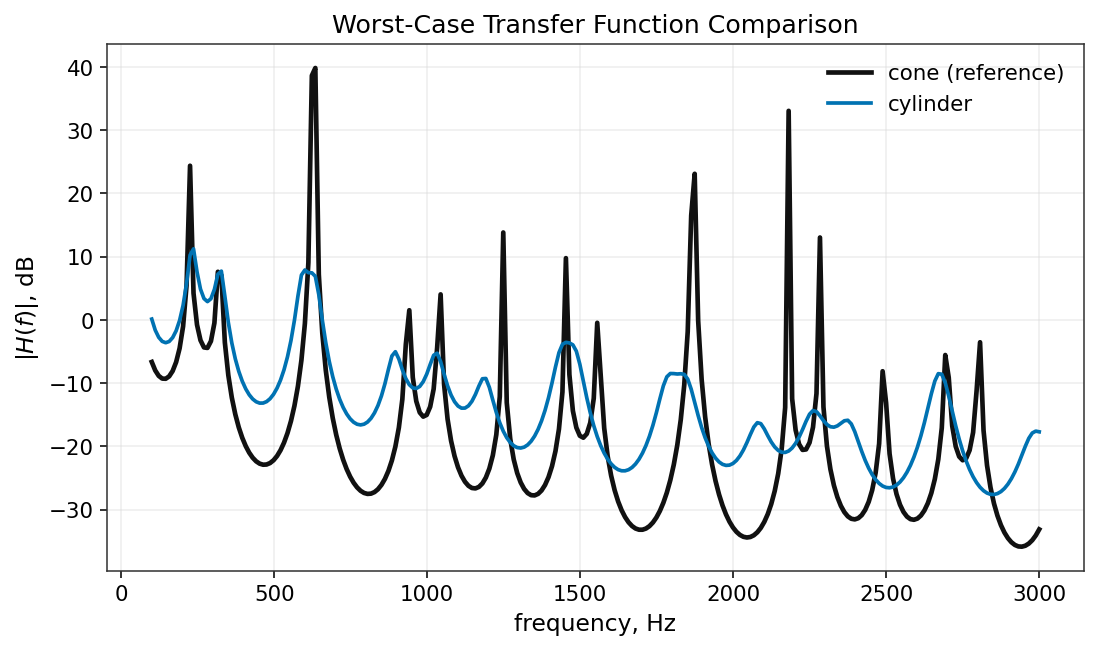

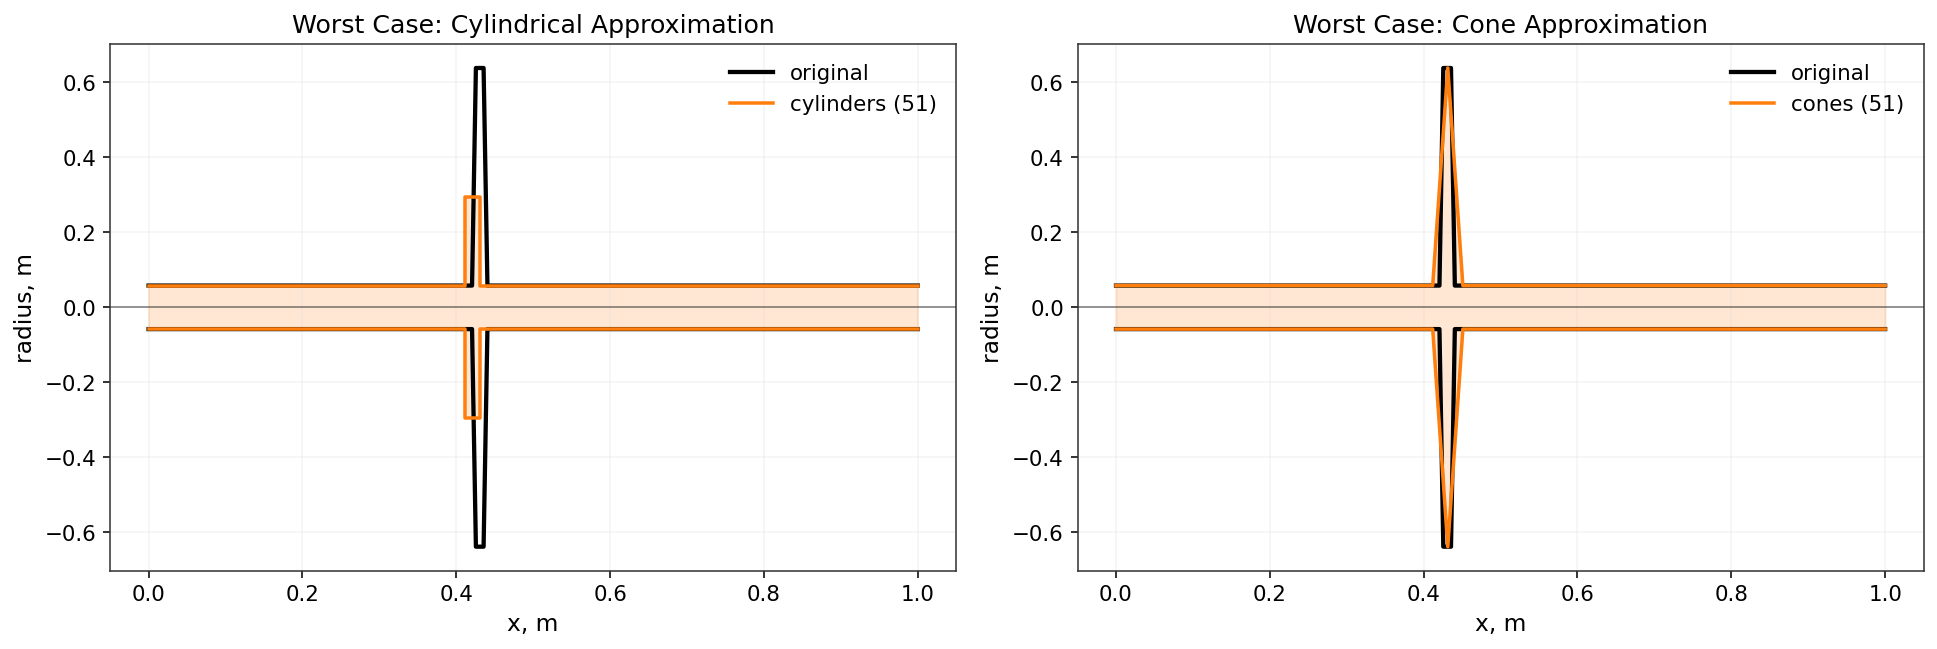

In [27]:
def magnitude_to_db(magnitude, eps=1e-12):
    return [20.0 * math.log10(max(abs(v), eps)) for v in magnitude]


ref_result = worst_case.comparison.results[reference_solver]
cmp_result = worst_case.comparison.results[worst_solver]

plt.figure(figsize=(8, 4.8))

plt.plot(
    ref_result.frequencies_hz,
    magnitude_to_db(ref_result.magnitude),
    color=COLORS["black"],
    linewidth=2.4,
    label=f"{reference_solver} (reference)",
)

plt.plot(
    cmp_result.frequencies_hz,
    magnitude_to_db(cmp_result.magnitude),
    color=COLORS["blue"],
    linewidth=1.9,
    label=worst_solver,
)

plt.xlabel("frequency, Hz")
plt.ylabel(r"$|H(f)|$, dB")
plt.title("Worst-Case Transfer Function Comparison")
plt.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

vt.plot_geometry_approximation(
    worst_case.geometry,
    section_count=quality_config.sections,
    approx="cylinders",
    mode="symmetric",
    ax=axes[0],
    title="Worst Case: Cylindrical Approximation",
    equal_aspect=False,
    linewidth_original=2.2,
    linewidth_approx=1.8,
)

vt.plot_geometry_approximation(
    worst_case.geometry,
    section_count=quality_config.sections,
    approx="cones",
    mode="symmetric",
    ax=axes[1],
    title="Worst Case: Cone Approximation",
    equal_aspect=False,
    linewidth_original=2.2,
    linewidth_approx=1.8,
)

plt.tight_layout()
plt.show()

In [28]:
import matplotlib.pyplot as plt

COLORS = {
    "original": "#0F172A",
    "cones": "#2563EB",
    "cylinders": "#F97316",
    "webster": "#059669",
    "arma": "#DB2777",
    "grid": "#CBD5E1",
    "axis": "#334155",
}

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 150,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.edgecolor": COLORS["axis"],
    "axes.linewidth": 0.9,
    "axes.grid": True,
    "grid.color": COLORS["grid"],
    "grid.linewidth": 0.8,
    "grid.alpha": 0.45,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.titleweight": "semibold",
    "axes.labelsize": 12,
    "axes.labelcolor": COLORS["axis"],
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "xtick.color": COLORS["axis"],
    "ytick.color": COLORS["axis"],
    "legend.fontsize": 11,
    "legend.frameon": False,
    "lines.solid_capstyle": "round",
    "lines.solid_joinstyle": "round",
})

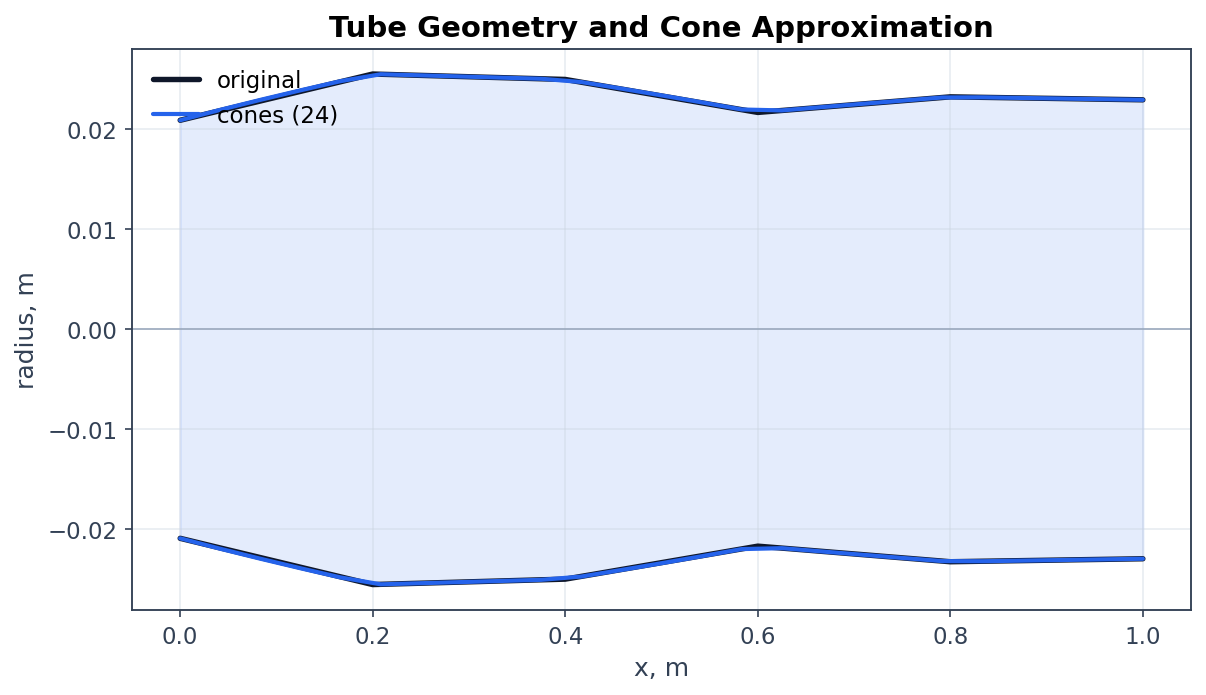

In [29]:
import math

geom = vt.make_geometry_from_range_library("random_piecewise", range_library, seed=1)
section_count = 24

fig, ax = plt.subplots(figsize=(8.2, 4.8))

x_m, area_m2 = vt.geometry_to_arrays(geom)
r_m = [math.sqrt(a / math.pi) for a in area_m2]

ax.plot(x_m, r_m, color=COLORS["original"], linewidth=2.6, label="original")
ax.plot(x_m, [-r for r in r_m], color=COLORS["original"], linewidth=2.6)

sections = vt.approximate_with_cones(geom, section_count)
xs = [sections[0]["left_x_m"]]
upper = [math.sqrt(sections[0]["area_in_m2"] / math.pi)]
for sec in sections:
    xs.append(sec["right_x_m"])
    upper.append(math.sqrt(sec["area_out_m2"] / math.pi))
lower = [-v for v in upper]

ax.plot(xs, upper, color=COLORS["cones"], linewidth=2.0, label=f"cones ({section_count})")
ax.plot(xs, lower, color=COLORS["cones"], linewidth=2.0)
ax.fill_between(xs, lower, upper, color=COLORS["cones"], alpha=0.12)

ax.axhline(0.0, color="#94A3B8", linewidth=0.9, alpha=0.8)
ax.set_xlabel("x, m")
ax.set_ylabel("radius, m")
ax.set_title("Tube Geometry and Cone Approximation")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

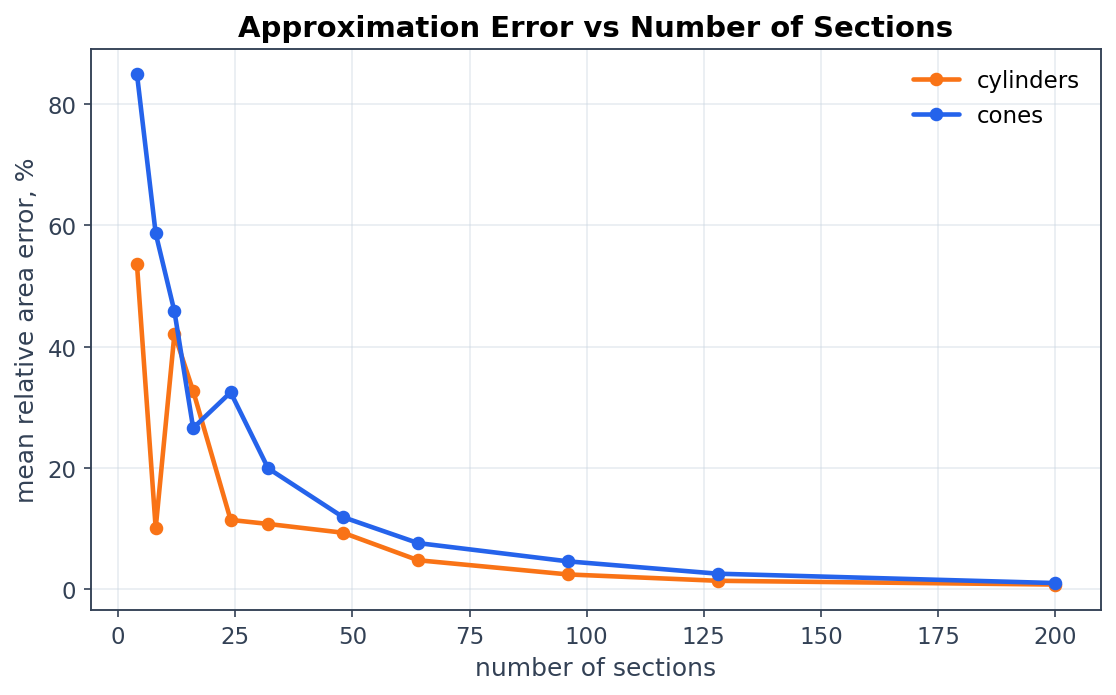

In [30]:
plt.figure(figsize=(7.6, 4.8))

plt.plot(
    section_counts,
    [100 * e for e in mean_err_cyl],
    marker="o",
    markersize=5.5,
    linewidth=2.2,
    color=COLORS["cylinders"],
    label="cylinders",
)

plt.plot(
    section_counts,
    [100 * e for e in mean_err_cone],
    marker="o",
    markersize=5.5,
    linewidth=2.2,
    color=COLORS["cones"],
    label="cones",
)

plt.xlabel("number of sections")
plt.ylabel("mean relative area error, %")
plt.title("Approximation Error vs Number of Sections")
plt.legend()
plt.tight_layout()
plt.show()

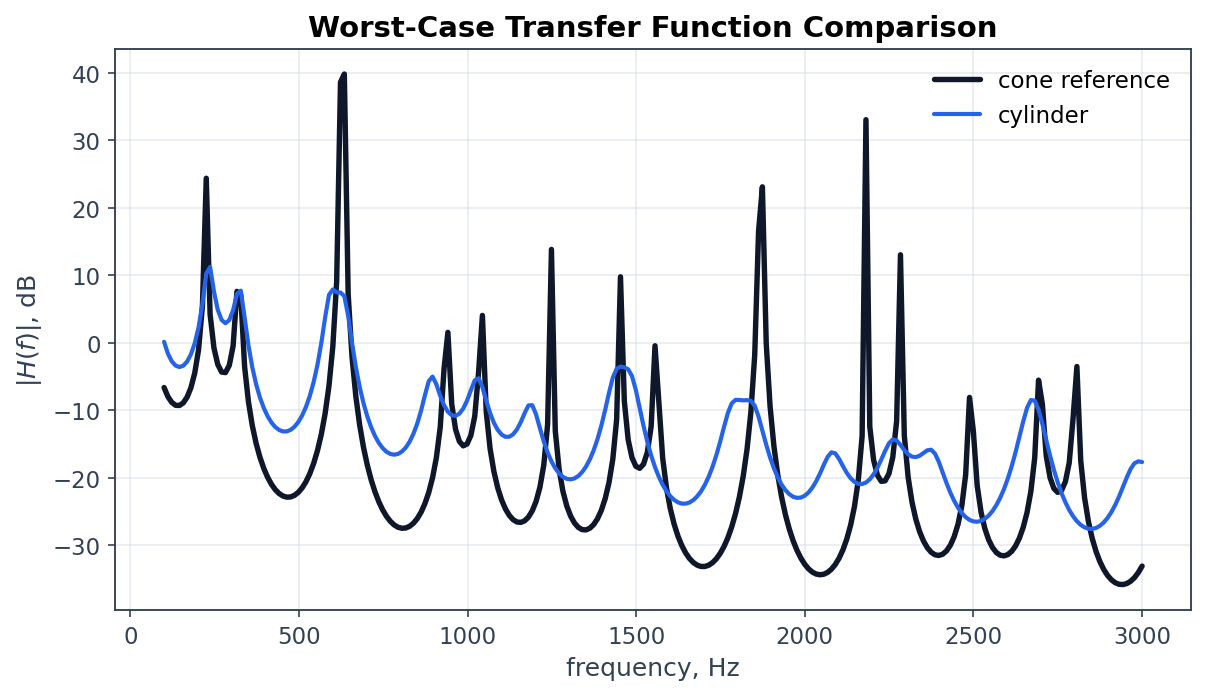

In [31]:
def magnitude_to_db(magnitude, eps=1e-12):
    return [20.0 * math.log10(max(abs(v), eps)) for v in magnitude]

ref_result = worst_case.comparison.results[reference_solver]
cmp_result = worst_case.comparison.results[worst_solver]

plt.figure(figsize=(8.2, 4.8))

plt.plot(
    ref_result.frequencies_hz,
    magnitude_to_db(ref_result.magnitude),
    color=COLORS["original"],
    linewidth=2.6,
    label=f"{reference_solver} reference",
)

plt.plot(
    cmp_result.frequencies_hz,
    magnitude_to_db(cmp_result.magnitude),
    color=COLORS["cones"],
    linewidth=2.0,
    label=worst_solver,
)

plt.xlabel("frequency, Hz")
plt.ylabel(r"$|H(f)|$, dB")
plt.title("Worst-Case Transfer Function Comparison")
plt.legend()

plt.tight_layout()
plt.show()

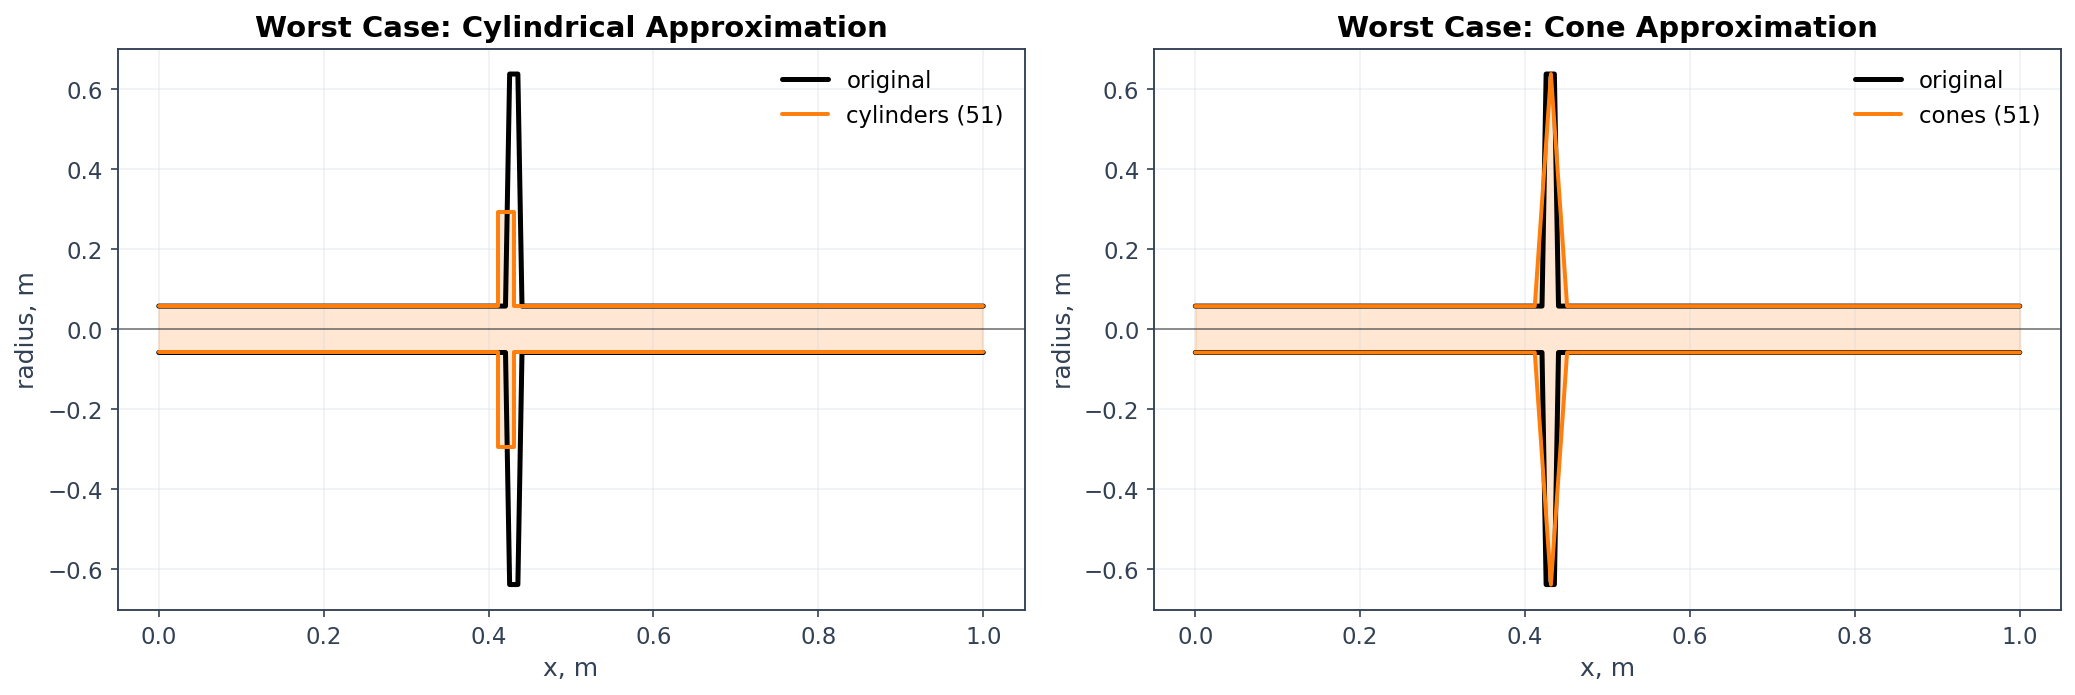

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

vt.plot_geometry_approximation(
    worst_case.geometry,
    section_count=quality_config.sections,
    approx="cylinders",
    mode="symmetric",
    ax=axes[0],
    title="Worst Case: Cylindrical Approximation",
    equal_aspect=False,
    linewidth_original=2.4,
    linewidth_approx=1.9,
)

vt.plot_geometry_approximation(
    worst_case.geometry,
    section_count=quality_config.sections,
    approx="cones",
    mode="symmetric",
    ax=axes[1],
    title="Worst Case: Cone Approximation",
    equal_aspect=False,
    linewidth_original=2.4,
    linewidth_approx=1.9,
)

plt.tight_layout()
plt.show()

## Датасет

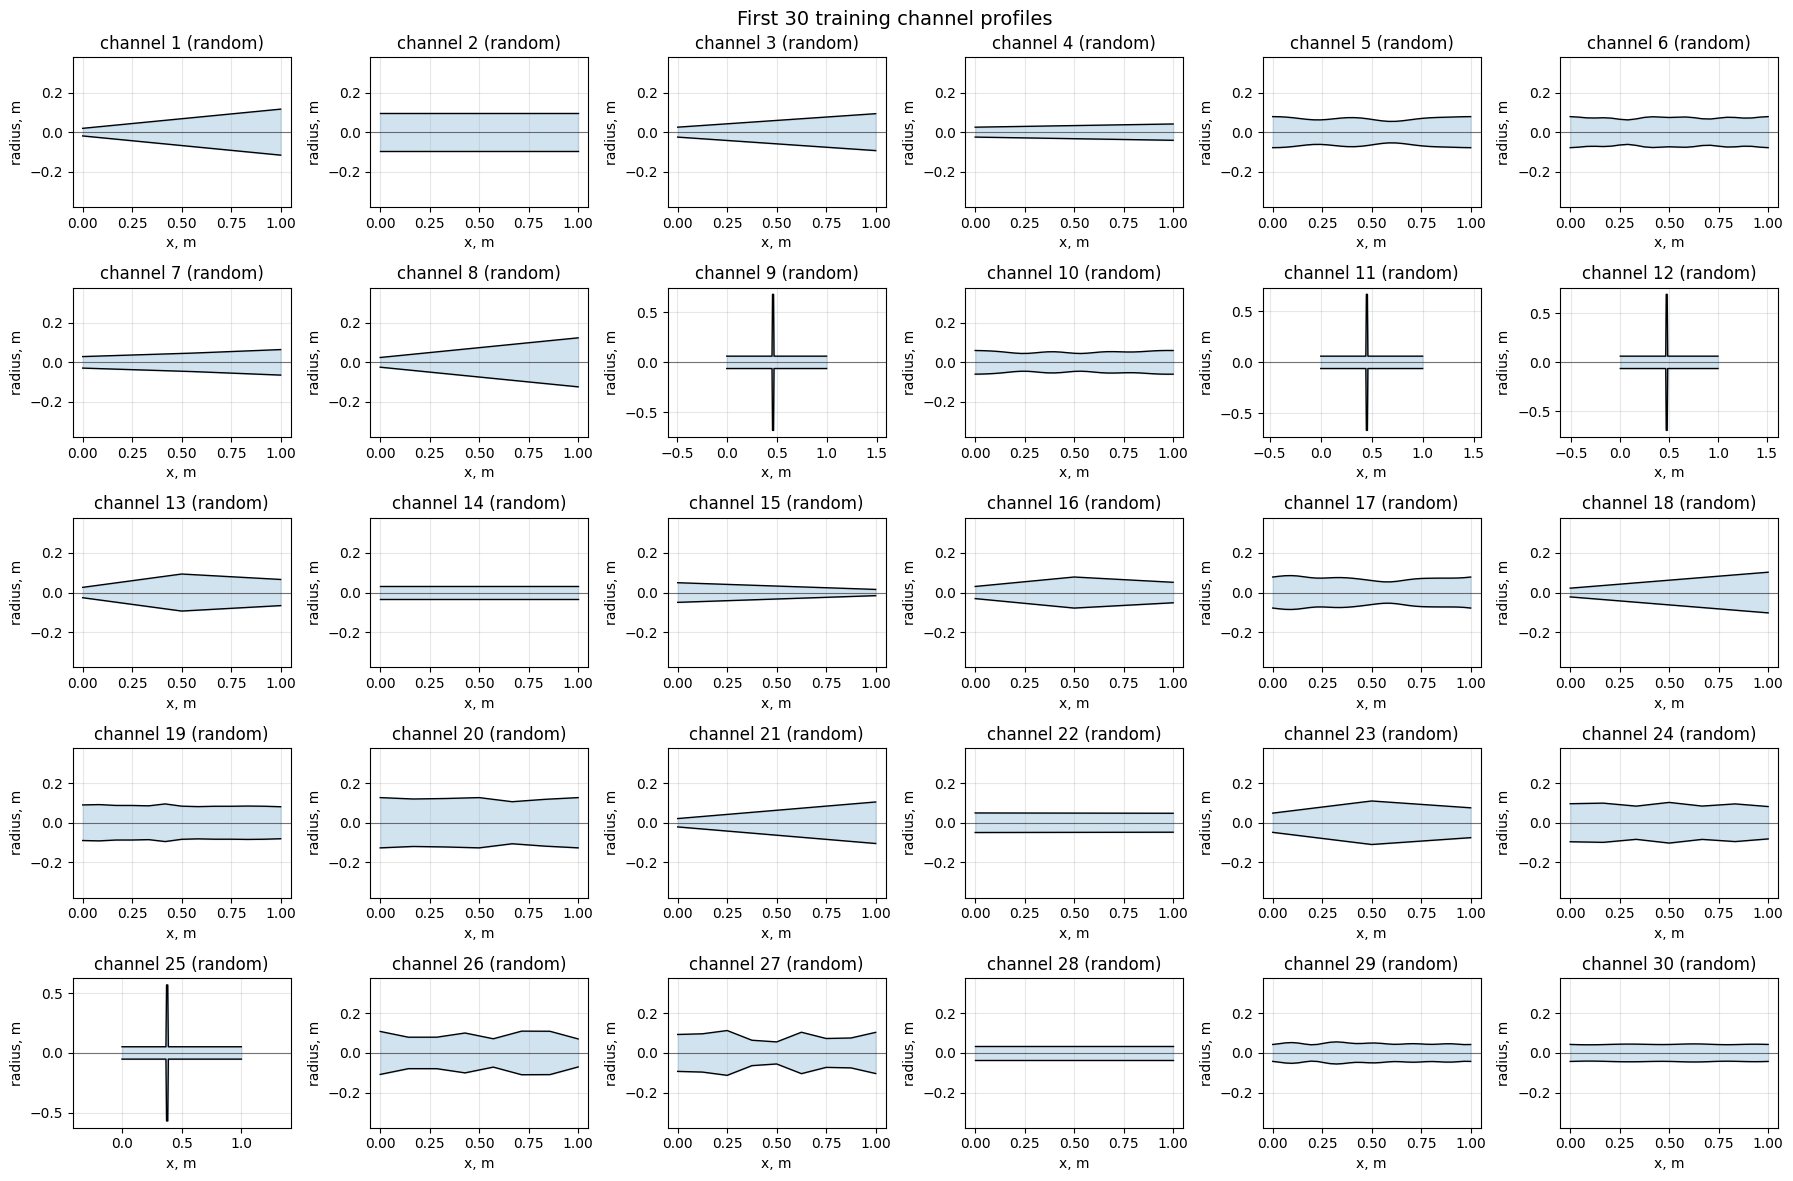

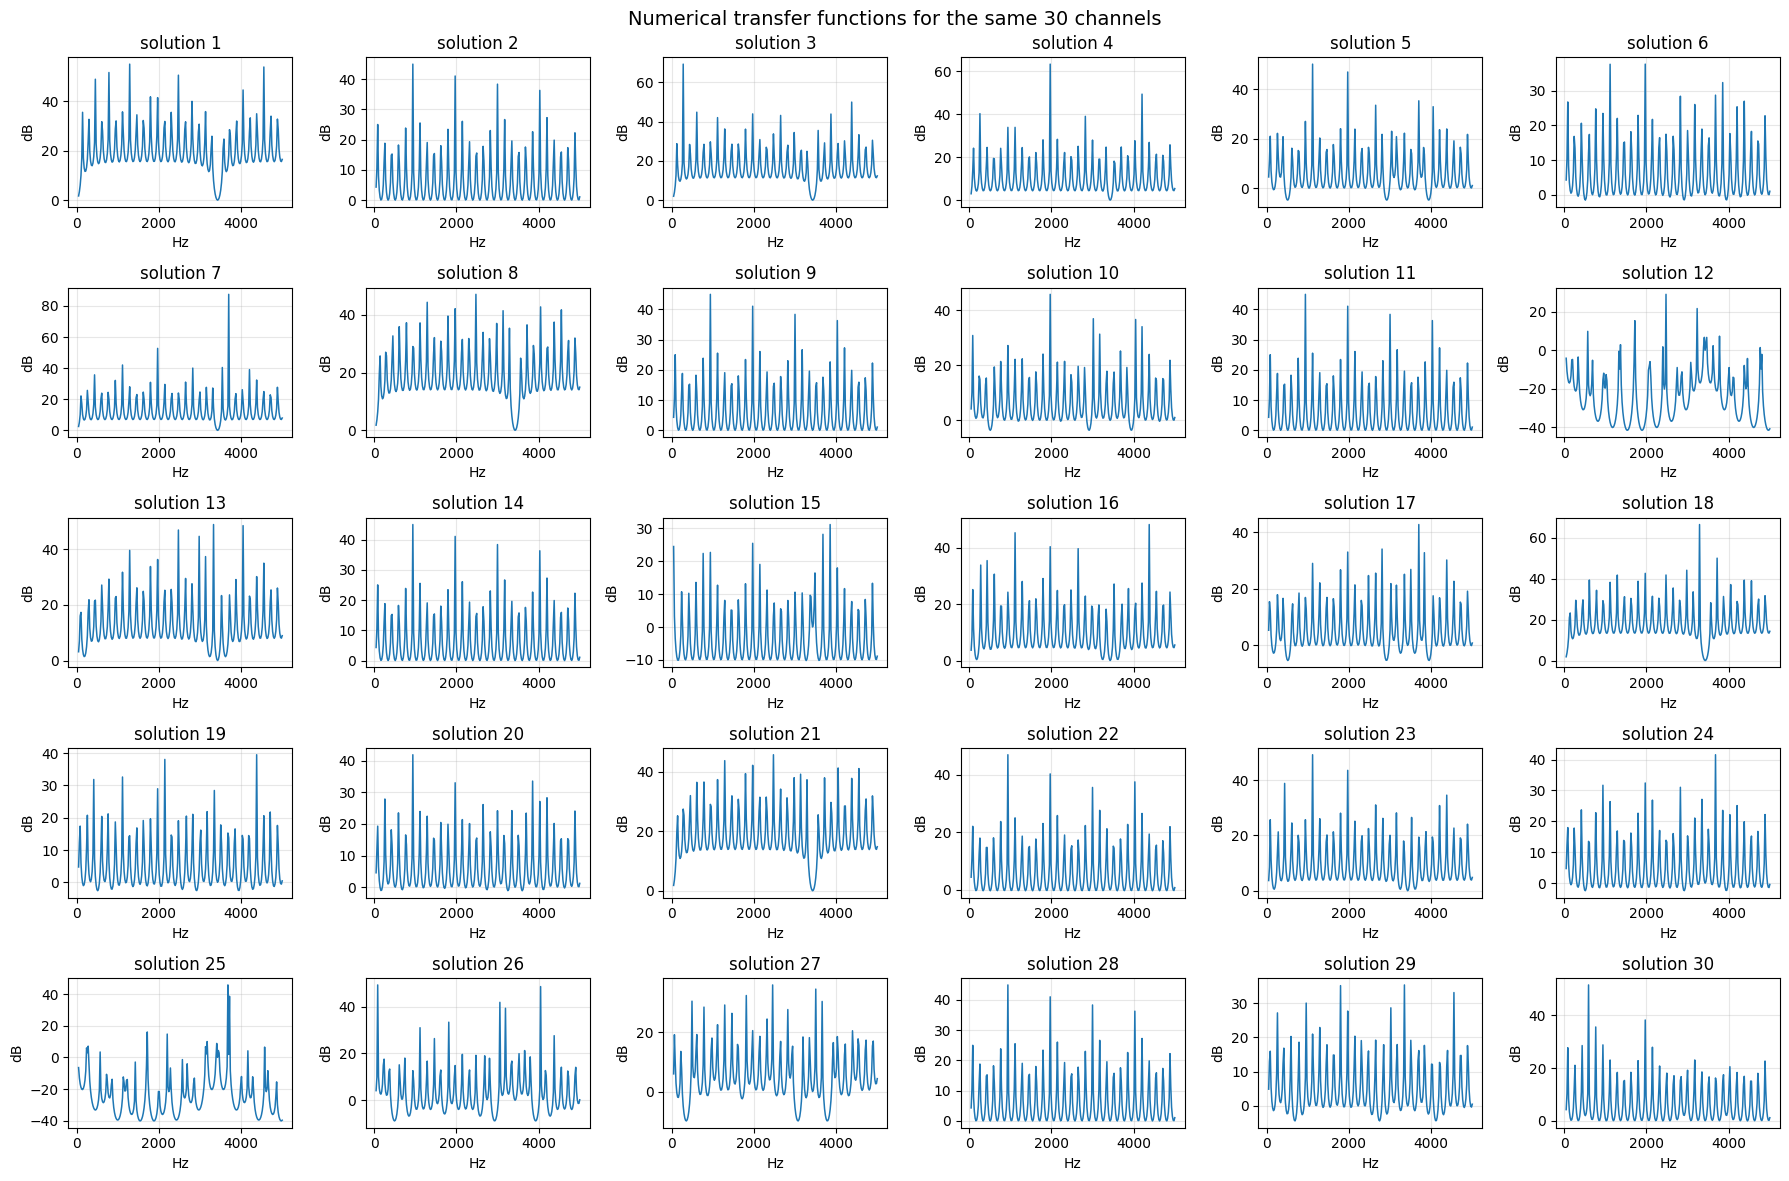

In [4]:
import importlib
import matplotlib.pyplot as plt
import vt_all_solvers_wrapper as vt
import dataset

from base_range_library import range_library
from dataset import StreamingGeometryDatasetConfig, make_streaming_dataloader

importlib.reload(vt)
importlib.reload(dataset)

batch_size = 50
n_show = 30

train_config = StreamingGeometryDatasetConfig(
    geometry_kind="random",
    target_mode="db",
    return_geometry=True,
    return_metadata=True,
    seed=1,
)

train_loader = make_streaming_dataloader(
    train_config,
    range_library,
    batch_size=batch_size,
    num_workers=0,
)

geometries = []
solutions_db = []
frequencies_hz = []
metadata = []

for batch in train_loader:
    geom = batch["geometry"]

    x = geom["x_m"]
    area = geom["area_m2"]
    node_count = geom["node_count"]

    target = batch["target"]
    freq = batch["frequencies_hz"]
    meta = batch.get("meta", None)

    for i in range(x.shape[0]):
        n = int(node_count[i])

        geometry = vt.ExplicitGeometry(
            x_m=x[i, :n].cpu().tolist(),
            area_m2=area[i, :n].cpu().tolist(),
        )

        geometries.append(geometry)
        solutions_db.append(target[i].detach().cpu())
        frequencies_hz.append(freq[i].detach().cpu())

        if meta is not None:
            metadata.append(meta[i])
        else:
            metadata.append(None)

        if len(geometries) >= n_show:
            break

    if len(geometries) >= n_show:
        break


# 1) Геометрии каналов
fig, axes = plt.subplots(5, 6, figsize=(18, 12))
axes = axes.ravel()

for idx, geometry in enumerate(geometries):
    kind = ""
    if metadata[idx] is not None and "geometry_kind" in metadata[idx]:
        kind = f" ({metadata[idx]['geometry_kind']})"
    elif metadata[idx] is not None and "geometry_kind_requested" in metadata[idx]:
        kind = f" ({metadata[idx]['geometry_kind_requested']})"

    vt.plot_geometry(
        geometry,
        mode="symmetric",
        ax=axes[idx],
        title=f"channel {idx + 1}{kind}",
        equal_aspect=True,
        linewidth=1.0,
    )

for ax in axes[len(geometries):]:
    ax.axis("off")

fig.suptitle("First 30 training channel profiles", fontsize=14)
fig.tight_layout()
plt.show()


# 2) Численные решения для тех же каналов
fig, axes = plt.subplots(5, 6, figsize=(18, 12))
axes = axes.ravel()

for idx, (freq, solution_db) in enumerate(zip(frequencies_hz, solutions_db)):
    axes[idx].plot(freq, solution_db, linewidth=1.1, color="tab:blue")
    axes[idx].set_title(f"solution {idx + 1}")
    axes[idx].set_xlabel("Hz")
    axes[idx].set_ylabel("dB")
    axes[idx].grid(True, alpha=0.3)

for ax in axes[len(solutions_db):]:
    ax.axis("off")

fig.suptitle("Numerical transfer functions for the same 30 channels", fontsize=14)
fig.tight_layout()
plt.show()